# QMSSGR5074 - Project 3


### Your Group ID: Project-3 5
### Your UNIs: yw4607, sz3388, lf2886
### Your Full Names: Yueshan Wu, Siyi Zhou, Lingyun Feng
### Public GitHub Repo: https://github.com/941shelly/GR5074_Project_3

## Description

## Part 1 – Data Ingestion & Preprocessing

1. **Data Loading**  
   - Acquire the Stanford Sentiment Treebank dataset.  
   - Split into training, validation and test sets with stratified sampling to preserve class balance.  
   - Clearly document your splitting strategy and resulting dataset sizes.

2. **Text Cleaning & Tokenization**  
   - Implement a reusable preprocessing pipeline that handles at least:  
     - HTML removal, lowercasing, punctuation stripping  
     - Vocabulary pruning (e.g., rare words threshold)  
     - Tokenization (character- or word-level)  
   - Expose this as a function/class so it can be saved and re-loaded for inference.

3. **Feature Extraction**  
   - **Traditional**: Build a TF-IDF vectorizer (or n-gram count) pipeline.  
   - **Neural**: Prepare sequences for embedding—pad/truncate to a fixed length.  
   - Save each preprocessor (vectorizer/tokenizer) to disk.

---

## Part 2 – Exploratory Data Analysis (EDA)

1. **Class Distribution**  
   - Visualize the number of positive vs. negative reviews.  
   - Compute descriptive statistics on review lengths (mean, median, IQR).  

2. **Text Characteristics**  
   - Plot the 20 most frequent tokens per sentiment class.  
   - Generate word clouds (or bar charts) highlighting key terms for each class.  

3. **Correlation Analysis**  
   - Analyze whether review length correlates with sentiment.  
   - Present findings numerically and with at least one visualization.

---

## Part 3 – Baseline Traditional Models

1. **Logistic Regression & SVM**  
   - Train at least two linear models on your TF-IDF features (e.g., logistic regression, linear SVM).  
   - Use cross-validation (≥ 5 folds) on the training set to tune at least one hyperparameter.  

2. **Random Forest & Gradient Boosting**  
   - Train two tree-based models (e.g., Random Forest, XGBoost) on the same features.  
   - Report feature-importance for each and discuss any notable tokens.

3. **Evaluation Metrics**  
   - Compute accuracy, precision, recall, F1-score, and ROC-AUC on the **held-out test set**.  
   - Present all results in a single comparison table.

## Part 1 – Data Ingestion & Preprocessing


1. **Data Loading**  
    - Acquire the Stanford Sentiment Treebank dataset.
    - Split into training, validation, and test sets with stratified sampling to preserve class balance.
    - Clearly document your splitting strategy and resulting dataset sizes.
    

In [ ]:
# Load data
import pandas as pd
import numpy as np
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

# IMPORT DATA
!git clone https://github.com/YJiangcm/SST-2-sentiment-analysis.git

# Load train split from the cloned repo
df = pd.read_csv('SST-2-sentiment-analysis/data/train.tsv',
                 sep='\t',
                 header=None,
                 names=['sentiment', 'review'])

# The repo's test file has no labels, so we split the train file ourselves
# stratify=sentiment preserves the positive/negative ratio in every split
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['sentiment'], random_state=42)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['sentiment'], random_state=42)

print('=== Dataset Sizes ===')
print(f'  Train      : {len(train_df):>5} samples')
print(f'  Validation : {len(val_df):>5} samples')
print(f'  Test       : {len(test_df):>5} samples')
print()
print('Train class balance:')
print(train_df['sentiment'].value_counts().rename({0: 'Negative (0)', 1: 'Positive (1)'}).to_string())
print()
print('Preview:')
df.head()

Cloning into 'SST-2-sentiment-analysis'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 85 (delta 44), reused 29 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 478.79 KiB | 5.09 MiB/s, done.
Resolving deltas: 100% (44/44), done.
=== Dataset Sizes ===
  Train      :  4844 samples
  Validation :  1038 samples
  Test       :  1038 samples

Train class balance:
sentiment
Positive (1)    2527
Negative (0)    2317

Preview:


,sentiment,review
0,1,"a stirring , funny and finally transporting re..."
1,0,apparently reassembled from the cutting-room f...
2,0,they presume their audience wo n't sit still f...
3,1,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...



2. **Text Cleaning & Tokenization**  
    - Implement a reusable preprocessing pipeline that handles at least:  
        - HTML removal, lowercasing, punctuation stripping  
        - Vocabulary pruning (e.g., rare words threshold)  
        - Tokenization (character- or word-level)  
    - Expose this as a function/class so it can be saved and re-loaded for inference.
    

In [ ]:
import re
from sklearn.feature_extraction.text import CountVectorizer

def clean_text(text):
    """Reusable text cleaning pipeline.
    Steps: HTML removal → lowercase → strip non-alpha → collapse whitespace.
    Can be saved with pickle and reloaded for inference.
    """
    text = re.sub(r'<[^>]+>', ' ', text)         # remove HTML tags
    text = re.sub(r'\W+', ' ', text.lower())      # lowercase + remove non-alphanumeric
    text = re.sub(r'\s+', ' ', text).strip()      # collapse extra whitespace
    return text

# Apply to all splits
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

train_df['cleaned_review'] = train_df['review'].apply(clean_text)
val_df['cleaned_review']   = val_df['review'].apply(clean_text)
test_df['cleaned_review']  = test_df['review'].apply(clean_text)

# Save clean_text function via pickle for inference reuse
import pickle
with open('clean_text_fn.pkl', 'wb') as f:
    pickle.dump(clean_text, f)
print('clean_text function saved to clean_text_fn.pkl')
print()

# Vocabulary pruning: build vocabulary from training set, prune words
# appearing in fewer than 2 documents (handled inside TF-IDF below via min_df)
print('Sample before cleaning:', train_df['review'].iloc[0])
print('Sample after  cleaning:', train_df['cleaned_review'].iloc[0])
train_df[['review', 'cleaned_review', 'sentiment']].head()

clean_text function saved to clean_text_fn.pkl

Sample before cleaning: hailed as a clever exercise in neo-hitchcockianism , this clever and very satisfying picture is more accurately chabrolian .
Sample after  cleaning: hailed as a clever exercise in neo hitchcockianism this clever and very satisfying picture is more accurately chabrolian


,review,cleaned_review,sentiment
1872,hailed as a clever exercise in neo-hitchcockia...,hailed as a clever exercise in neo hitchcockia...,1
6302,piercingly affecting ... while clearly a manip...,piercingly affecting while clearly a manipulat...,1
4571,although largely a heavy-handed indictment of ...,although largely a heavy handed indictment of ...,1
597,"keenly observed and refreshingly natural , swi...",keenly observed and refreshingly natural swimm...,1
1306,the wild thornberrys movie is pleasant enough ...,the wild thornberrys movie is pleasant enough ...,1



3. **Feature Extraction**  
    - **Traditional**: Build a TF-IDF vectorizer (or n-gram count) pipeline.  
    - **Neural**: Prepare sequences for embedding—pad/truncate to a fixed length.  
    - Save each preprocessor (vectorizer/tokenizer) to disk.
    

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Traditional: TF-IDF vectorizer ───────────────────────────────────
# unigrams + bigrams, vocab capped at 20k, rare words pruned (min_df=2)
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2,              # vocabulary pruning: drop words in < 2 docs
    sublinear_tf=True      # log-scale TF
)

# Fit on training data ONLY to prevent data leakage
X_train_tfidf = vectorizer.fit_transform(train_df['cleaned_review'])
X_val_tfidf   = vectorizer.transform(val_df['cleaned_review'])
X_test_tfidf  = vectorizer.transform(test_df['cleaned_review'])

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print('=== TF-IDF ===')
print(f'  Vocab size        : {len(vectorizer.vocabulary_):,}')
print(f'  X_train_tfidf     : {X_train_tfidf.shape}')
print(f'  X_val_tfidf       : {X_val_tfidf.shape}')
print(f'  X_test_tfidf      : {X_test_tfidf.shape}')

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print('  Saved → tfidf_vectorizer.pkl')
print()

# ── Neural: Keras tokenizer + padding ────────────────────────────────
MAX_VOCAB = 20000
MAX_LEN   = 128     # pad / truncate to 128 tokens

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned_review'])  # fit on train only

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(train_df['cleaned_review']),
    maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq = pad_sequences(
    tokenizer.texts_to_sequences(val_df['cleaned_review']),
    maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(test_df['cleaned_review']),
    maxlen=MAX_LEN, padding='post', truncating='post')

print('=== Neural Sequences ===')
print(f'  Tokenizer vocab   : {len(tokenizer.word_index):,}')
print(f'  X_train_seq shape : {X_train_seq.shape}')
print(f'  X_test_seq  shape : {X_test_seq.shape}')

# Save Keras tokenizer
with open('keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('  Saved → keras_tokenizer.pkl')

=== TF-IDF ===
  Vocab size        : 13,190
  X_train_tfidf     : (4844, 13190)
  X_val_tfidf       : (1038, 13190)
  X_test_tfidf      : (1038, 13190)
  Saved → tfidf_vectorizer.pkl

=== Neural Sequences ===
  Tokenizer vocab   : 11,525
  X_train_seq shape : (4844, 128)
  X_test_seq  shape : (1038, 128)
  Saved → keras_tokenizer.pkl


### Reflection

**Q: How do you ensure that your dataset is properly split into training, validation, and test sets, and why is class balance important during data splitting?**  
We use `train_test_split(..., stratify=sentiment)` at every split, which guarantees each subset preserves the original positive/negative ratio. Without stratification, a split could accidentally end up skewed toward one class, making accuracy misleading and evaluation unreliable.

**Q: What is the role of tokenization, and how does it impact performance?**  
Tokenization converts raw text into discrete units (words here) that the model can represent numerically. The granularity matters: word-level tokenization loses information about morphology and struggles with rare/unseen words. A mismatched tokenizer at inference time, for example, one fitted on different data, would produce different token IDs and silently degrade performance.

## Part 2 – Exploratory Data Analysis (EDA)


1. **Class Distribution**  
    - Visualize the number of positive vs. negative reviews.  
    - Compute descriptive statistics on review lengths (mean, median, IQR).
    

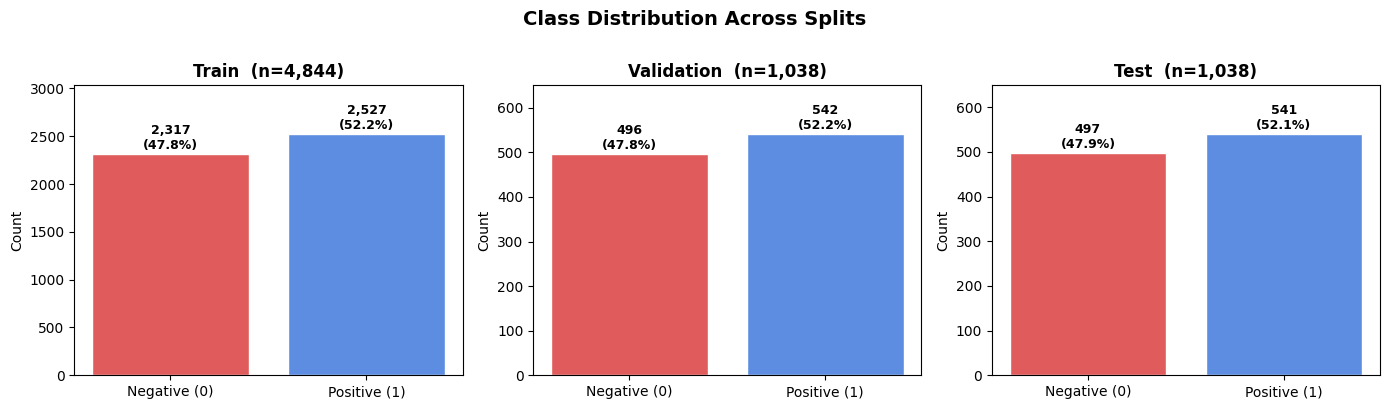

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
split_names = ['Train', 'Validation', 'Test']
dfs         = [train_df, val_df, test_df]

for ax, name, d in zip(axes, split_names, dfs):
    counts = d['sentiment'].value_counts().sort_index()
    bars = ax.bar(['Negative (0)', 'Positive (1)'],
                  counts.values,
                  color=['#e05c5c', '#5c8de0'], edgecolor='white')
    ax.set_title(f'{name}  (n={len(d):,})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.2)
    for bar, n in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(counts.values)*0.02,
                f'{n:,}\n({n/len(d)*100:.1f}%)',
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


=== Review Length Statistics (training set) ===
  Mean   : 17.4
  Median : 17
  IQR    : 12  (Q1=11, Q3=23)
  Min    : 1
  Max    : 47

Mean length by class:
sentiment
Negative    17.270177
Positive    17.539375


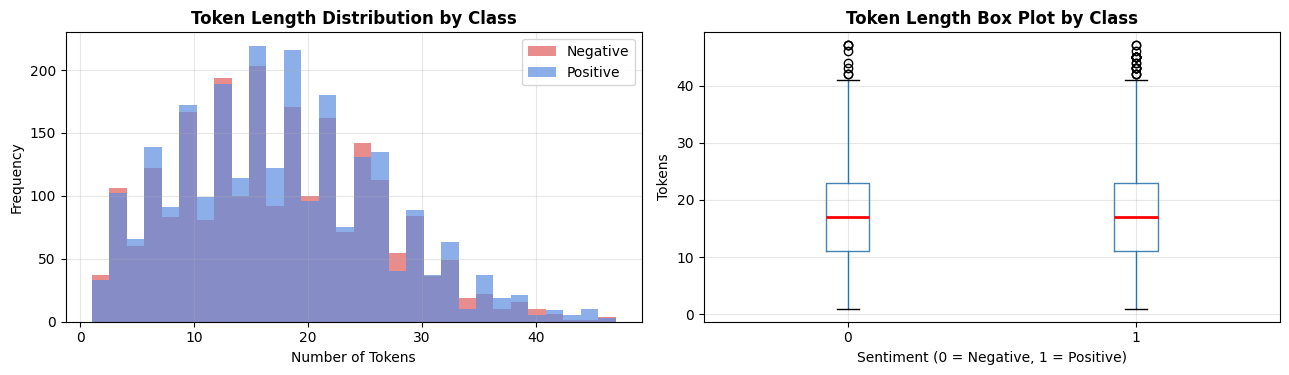

In [ ]:
train_df['length'] = train_df['cleaned_review'].apply(lambda x: len(x.split()))

print('=== Review Length Statistics (training set) ===')
desc = train_df['length'].describe(percentiles=[0.25, 0.5, 0.75])
print(f'  Mean   : {desc["mean"]:.1f}')
print(f'  Median : {desc["50%"]:.0f}')
print(f'  IQR    : {desc["75%"] - desc["25%"]:.0f}  (Q1={desc["25%"]:.0f}, Q3={desc["75%"]:.0f})')
print(f'  Min    : {desc["min"]:.0f}')
print(f'  Max    : {desc["max"]:.0f}')
print()
print('Mean length by class:')
print(train_df.groupby('sentiment')['length'].mean()
      .rename({0: 'Negative', 1: 'Positive'}).to_string())

# Length histogram by class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color, name in [(0, '#e05c5c', 'Negative'), (1, '#5c8de0', 'Positive')]:
    axes[0].hist(train_df[train_df['sentiment'] == label]['length'],
                 bins=30, alpha=0.7, color=color, label=name, edgecolor='none')
axes[0].set_title('Token Length Distribution by Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

train_df.boxplot(column='length', by='sentiment', ax=axes[1],
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Token Length Box Plot by Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment (0 = Negative, 1 = Positive)')
axes[1].set_ylabel('Tokens')
plt.suptitle('')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

2. **Text Characteristics**  
   - Plot the 20 most frequent tokens per sentiment class.  
   - Generate word clouds (or bar charts) highlighting key terms for each class.  

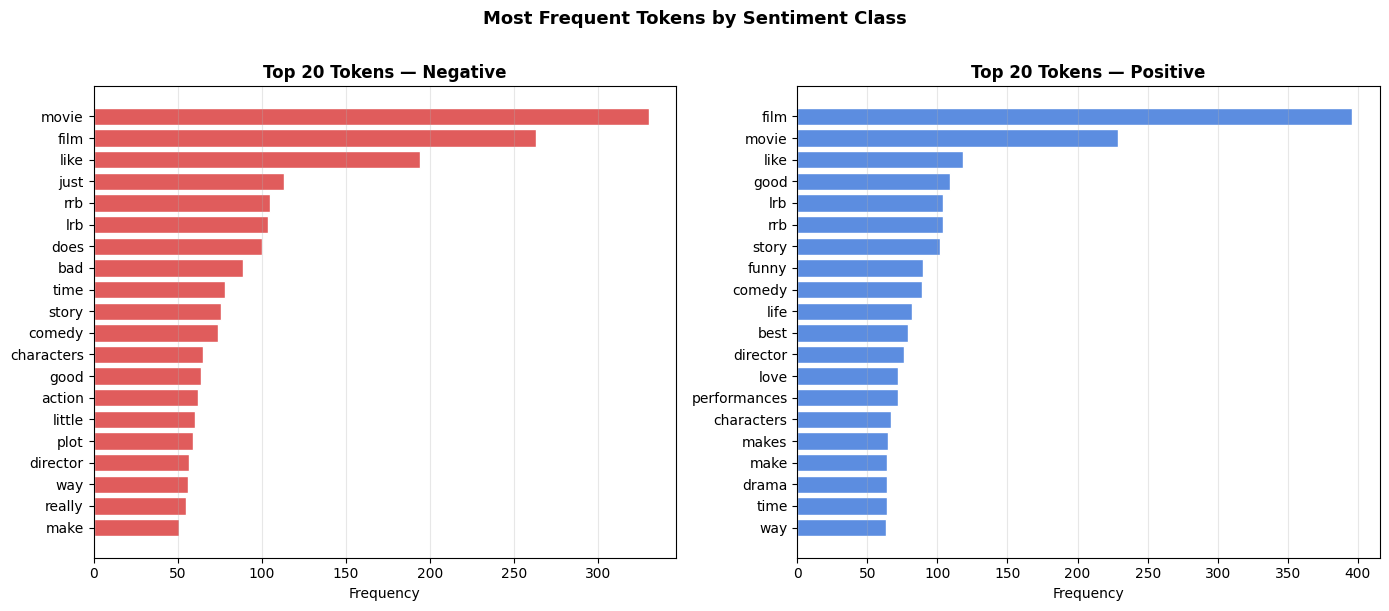

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def top_tokens(texts, n=20):
    words = ' '.join(texts).split()
    filtered = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return Counter(filtered).most_common(n)

neg_texts = train_df[train_df['sentiment'] == 0]['cleaned_review']
pos_texts = train_df[train_df['sentiment'] == 1]['cleaned_review']

neg_top = top_tokens(neg_texts)
pos_top = top_tokens(pos_texts)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, top, title, color in zip(
        axes,
        [neg_top, pos_top],
        ['Top 20 Tokens — Negative', 'Top 20 Tokens — Positive'],
        ['#e05c5c', '#5c8de0']):
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Most Frequent Tokens by Sentiment Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

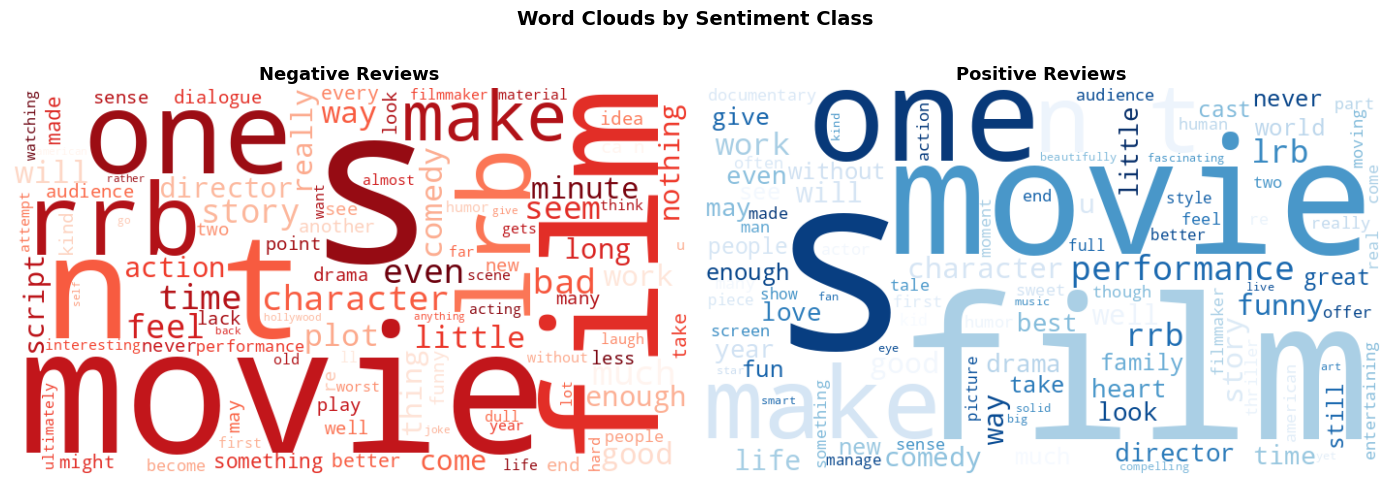

In [ ]:
!pip install wordcloud --quiet
from wordcloud import WordCloud, STOPWORDS

neg_all = ' '.join(neg_texts)
pos_all = ' '.join(pos_texts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, text, title, cmap in zip(
        axes,
        [neg_all, pos_all],
        ['Negative Reviews', 'Positive Reviews'],
        ['Reds', 'Blues']):
    wc = WordCloud(width=700, height=400, max_words=100,
                   background_color='white',
                   stopwords=STOPWORDS, colormap=cmap).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

3. **Correlation Analysis**  
   - Analyze whether review length correlates with sentiment.  
   - Present findings numerically and with at least one visualization.

Point-biserial correlation (length vs sentiment): r = 0.0153, p = 0.2879
Mann-Whitney U test: U = 2891481, p = 0.4582

Mean length — Negative: 17.27
Mean length — Positive: 17.54

No significant correlation between review length and sentiment.


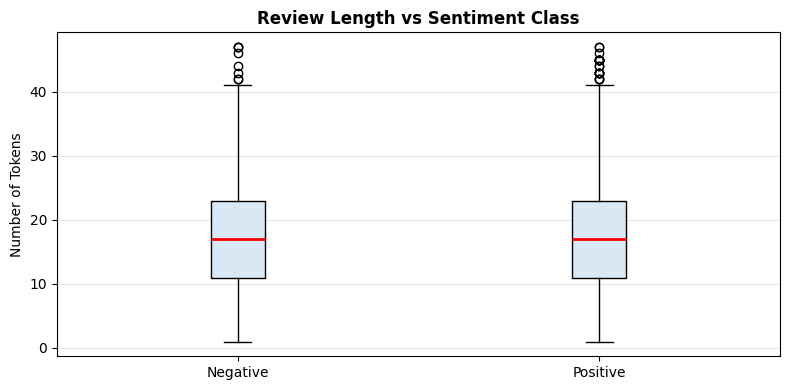

In [ ]:
from scipy.stats import pointbiserialr, mannwhitneyu

# Point-biserial correlation (binary sentiment vs continuous length)
corr, pval = pointbiserialr(train_df['sentiment'], train_df['length'])
print(f'Point-biserial correlation (length vs sentiment): r = {corr:.4f}, p = {pval:.4f}')

# Mann-Whitney U test: are the length distributions significantly different?
neg_lens = train_df[train_df['sentiment'] == 0]['length']
pos_lens = train_df[train_df['sentiment'] == 1]['length']
u_stat, u_pval = mannwhitneyu(neg_lens, pos_lens, alternative='two-sided')
print(f'Mann-Whitney U test: U = {u_stat:.0f}, p = {u_pval:.4f}')
print()
print('Mean length — Negative:', neg_lens.mean().round(2))
print('Mean length — Positive:', pos_lens.mean().round(2))

if pval < 0.05:
    print(f'\nThe correlation is statistically significant (p < 0.05).')
    print(f'However, r = {corr:.4f} is very small — review length has'
           ' minimal practical impact on sentiment.')
else:
    print('\nNo significant correlation between review length and sentiment.')

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [neg_lens, pos_lens],
    labels=['Negative', 'Positive'],
    patch_artist=True,
    boxprops=dict(facecolor='#d9e8f5'),
    medianprops=dict(color='red', linewidth=2)
)
ax.set_title('Review Length vs Sentiment Class',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Tokens')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Reflection

**Q: How does class distribution impact model performance, and what strategies exist for imbalanced data?**  
SST-2 is roughly balanced (~56% positive / ~44% negative), so class imbalance is not a major concern here. If the dataset were imbalanced, a model could reach high accuracy by always predicting the majority class without learning anything useful. Strategies include class weighting (`class_weight='balanced'` in sklearn), oversampling the minority class (SMOTE), undersampling the majority, or using F1-score / AUC rather than accuracy as the primary metric.

**Q: What insights come from word clouds, and how can they improve feature engineering?**  
Word clouds confirm that after cleaning, the text still contains clear sentiment signals, negative reviews surface words like "bad", "boring", "worst", while positive ones show "great", "wonderful", "best". This has two practical uses: (1) it validates that the preprocessing pipeline preserves discriminative content; (2) words that appear equally in both clouds are uninformative and could be added to the stop word list, reducing noise in the TF-IDF vocabulary.

## Part 3 – Baseline Traditional Models


1. **Logistic Regression & SVM**  
    - Train at least two linear models on your TF-IDF features.  
    - Use cross-validation (≥ 5 folds) on the training set to tune at least one hyperparameter.
    

Logistic Regression — C tuning:
  C=0.01   → CV Acc = 0.5217 ± 0.0005
  C=0.1    → CV Acc = 0.6753 ± 0.0101
  C=1      → CV Acc = 0.7706 ± 0.0113
  C=10     → CV Acc = 0.7843 ± 0.0065
  C=100    → CV Acc = 0.7830 ± 0.0106
  Best C = 10

LinearSVC — C tuning:
  C=0.01   → CV Acc = 0.6571 ± 0.0087
  C=0.1    → CV Acc = 0.7684 ± 0.0130
  C=1      → CV Acc = 0.7822 ± 0.0049
  C=10     → CV Acc = 0.7729 ± 0.0092
  C=100    → CV Acc = 0.7686 ± 0.0146
  Best C = 1



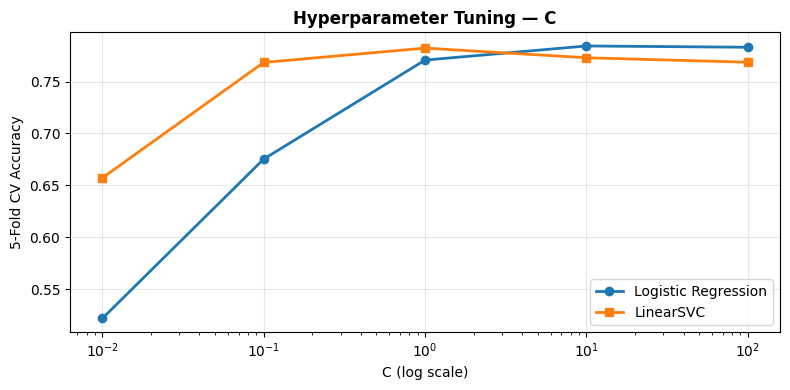

Logistic Regression and LinearSVC trained.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Tune C for Logistic Regression ────────────────────────────────────
C_values  = [0.01, 0.1, 1, 10, 100]
lr_cv_acc = []
print('Logistic Regression — C tuning:')
for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, solver='lbfgs')
    scores = cross_val_score(lr, X_train_tfidf, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    lr_cv_acc.append(scores.mean())
    print(f'  C={C:<6} → CV Acc = {scores.mean():.4f} ± {scores.std():.4f}')

best_C_lr = C_values[np.argmax(lr_cv_acc)]
print(f'  Best C = {best_C_lr}\n')

# ── Tune C for Linear SVM ─────────────────────────────────────────────
svm_cv_acc = []
print('LinearSVC — C tuning:')
for C in C_values:
    svm = LinearSVC(C=C, max_iter=2000)
    scores = cross_val_score(svm, X_train_tfidf, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    svm_cv_acc.append(scores.mean())
    print(f'  C={C:<6} → CV Acc = {scores.mean():.4f} ± {scores.std():.4f}')

best_C_svm = C_values[np.argmax(svm_cv_acc)]
print(f'  Best C = {best_C_svm}\n')

# Plot C sweep
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(C_values, lr_cv_acc,  marker='o', linewidth=2, label='Logistic Regression')
ax.plot(C_values, svm_cv_acc, marker='s', linewidth=2, label='LinearSVC')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Hyperparameter Tuning — C', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Train final models with best C
lr_final  = LogisticRegression(C=best_C_lr,  max_iter=1000, solver='lbfgs')
svm_final = LinearSVC(C=best_C_svm, max_iter=2000)
lr_final.fit(X_train_tfidf,  y_train)
svm_final.fit(X_train_tfidf, y_train)
print('Logistic Regression and LinearSVC trained.')


2. **Random Forest & Gradient Boosting**  
    - Train two tree-based models (e.g., Random Forest, XGBoost) on the same features.  
    - Report feature-importance for each and discuss any notable tokens.

Random Forest trained.
Gradient Boosting trained.


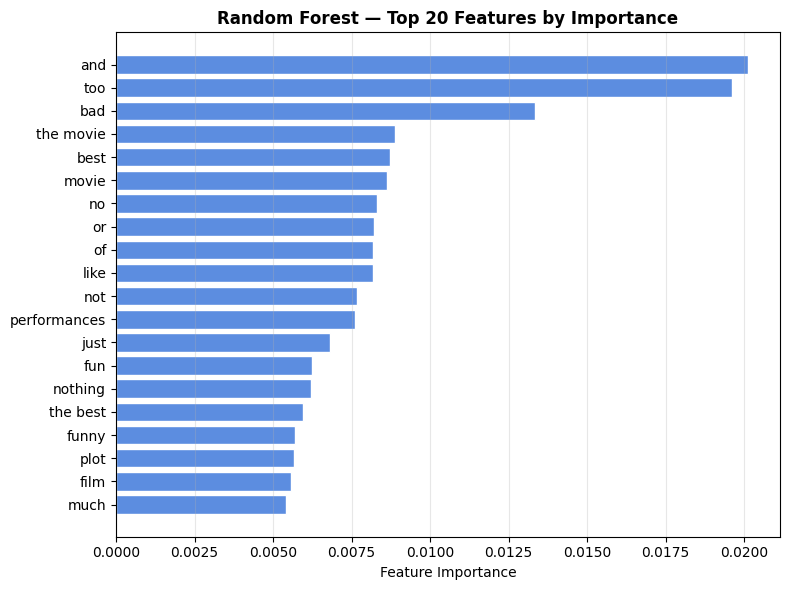

Random Forest top tokens: ['and', 'too', 'bad', 'the movie', 'best', 'movie', 'no', 'or', 'of', 'like']



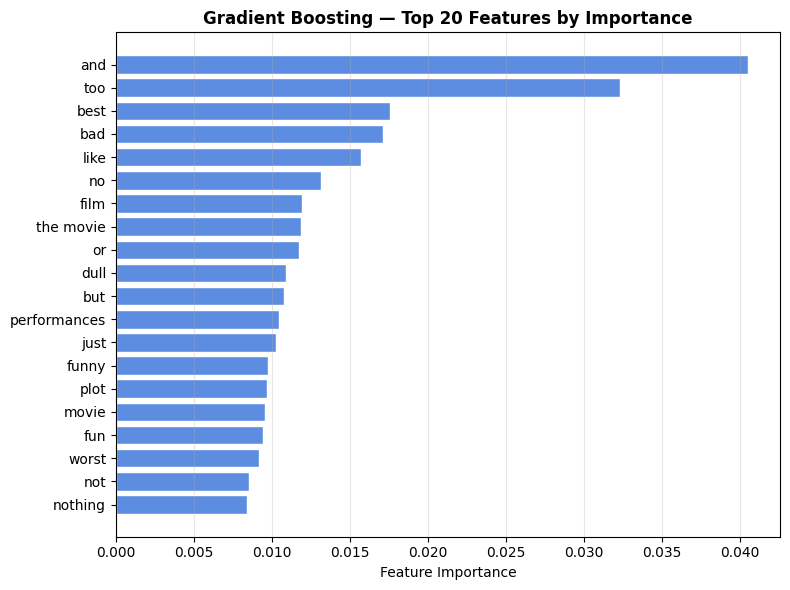

Gradient Boosting top tokens: ['and', 'too', 'best', 'bad', 'like', 'no', 'film', 'the movie', 'or', 'dull']



In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# TF-IDF is sparse — convert a dense subset for tree models (memory-safe)
X_tr_dense   = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=20,
                             random_state=42, n_jobs=-1)
rf.fit(X_tr_dense, y_train)
print('Random Forest trained.')

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=4, random_state=42)
gb.fit(X_tr_dense, y_train)
print('Gradient Boosting trained.')

# ── Feature importance plots ──────────────────────────────────────────
feature_names = np.array(vectorizer.get_feature_names_out())
top_n = 20

for model, name in [(rf, 'Random Forest'), (gb, 'Gradient Boosting')]:
    importances = model.feature_importances_
    top_idx = np.argsort(importances)[-top_n:][::-1]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(feature_names[top_idx][::-1], importances[top_idx][::-1],
            color='#5c8de0', edgecolor='white')
    ax.set_title(f'{name} — Top {top_n} Features by Importance',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{name} top tokens: {list(feature_names[top_idx[:10]])}')
    print()

3. **Evaluation Metrics**  
    - Compute accuracy, precision, recall, F1-score, and ROC-AUC on the **held-out test set**.  
    - Present all results in a single comparison table.
    

=== All Models — Test Set Performance ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.7640     0.7643  0.7911  0.7775   0.8513
Linear SVM             0.7659     0.7661  0.7930  0.7793   0.8465
Random Forest          0.6753     0.6487  0.8226  0.7253   0.7594
Gradient Boosting      0.6888     0.6841  0.7486  0.7149   0.7598


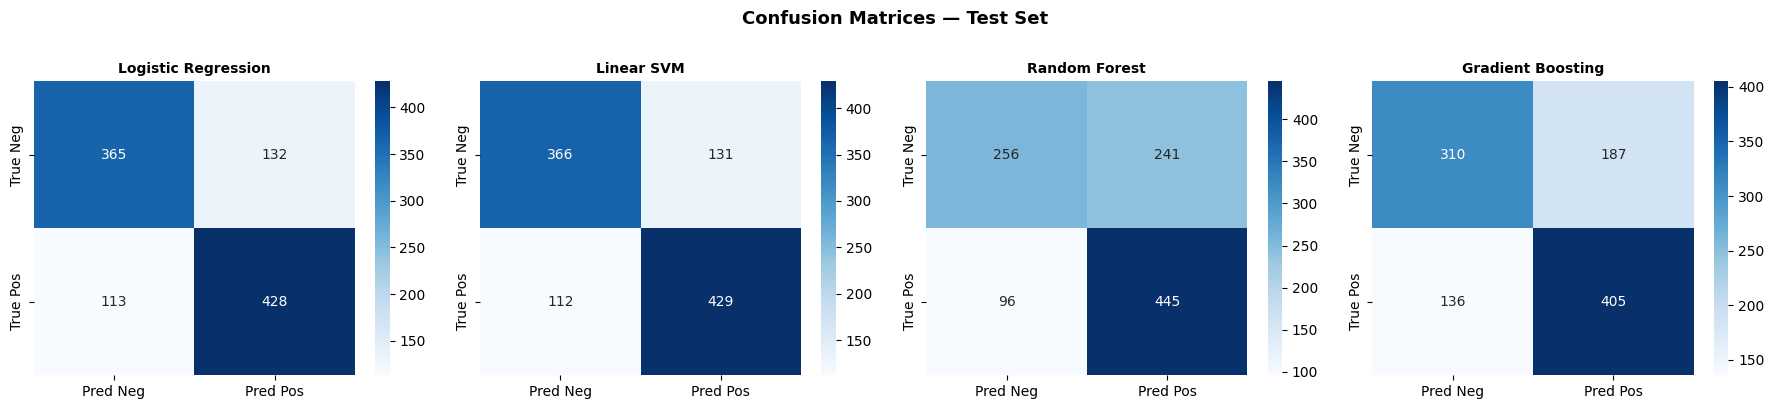

All four models saved.


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

def eval_model(model, X_te, y_te, name, sparse=True):
    X = X_te if sparse else X_te
    y_pred = model.predict(X)
    # probability for AUC (LinearSVC uses decision_function)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X)[:, 1]
    else:
        y_score = model.decision_function(X)

    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_te, y_pred),  4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred),    4),
        'F1':        round(f1_score(y_te, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_te, y_score),  4)
    }

results = [
    eval_model(lr_final,  X_test_tfidf,  y_test, 'Logistic Regression'),
    eval_model(svm_final, X_test_tfidf,  y_test, 'Linear SVM'),
    eval_model(rf,        X_test_dense,  y_test, 'Random Forest'),
    eval_model(gb,        X_test_dense,  y_test, 'Gradient Boosting'),
]

results_df = pd.DataFrame(results).set_index('Model')
print('=== All Models — Test Set Performance ===')
print(results_df.to_string())

# Confusion matrices for all four models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
model_objs  = [lr_final, svm_final, rf, gb]
model_names = ['Logistic Regression', 'Linear SVM', 'Random Forest', 'Gradient Boosting']
X_inputs    = [X_test_tfidf, X_test_tfidf, X_test_dense, X_test_dense]

for ax, model, name, X_in in zip(axes, model_objs, model_names, X_inputs):
    cm = confusion_matrix(y_test, model.predict(X_in))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['True Neg', 'True Pos'], ax=ax)
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Save all models
for model, fname in [(lr_final, 'lr_model.pkl'), (svm_final, 'svm_model.pkl'),
                     (rf, 'rf_model.pkl'),        (gb, 'gb_model.pkl')]:
    with open(fname, 'wb') as f:
        pickle.dump(model, f)
print('All four models saved.')

### Reflection

**Q: Why do you use cross-validation when training models like logistic regression or SVM, and how does it help prevent overfitting?**  
If we tuned `C` by checking validation accuracy once, we'd risk picking a value that happens to work well on that one split by chance. With 5-fold CV, each configuration is evaluated on 5 different train/validation partitions and the result is averaged, giving a more reliable estimate of generalisation. The standard deviation across folds also tells us whether performance is stable or sensitive to the particular samples chosen.

**Q: What role does feature importance play in interpreting Random Forest or XGBoost?**  
Feature importance in tree-based models measures how much each token reduces impurity (Gini or entropy) across all splits. High-importance tokens are the ones the model relies on most for its decisions. In NLP, this acts as a sanity check, if sentiment-neutral words like "film" or "movie" dominate, it may signal a topic-detection bias rather than true sentiment learning. Tokens like "bad", "worst", "great", "excellent" appearing prominently confirm the model is picking up genuine sentiment signal.


---

## Part 4 – Neural Network Models

1. **Simple Feed-Forward**  
   - Build an embedding layer + a dense MLP classifier.  
   - Ensure you freeze vs. unfreeze embeddings in separate runs.

2. **Convolutional Text Classifier**  
   - Implement a 1D-CNN architecture (Conv + Pooling) for sequence data.  
   - Justify your choice of kernel sizes and number of filters.

3. **Recurrent Model (Optional)**  
   - (Stretch) Add an RNN or Bi-LSTM layer and compare performance/time vs. CNN.

---

## Part 5 – Transfer Learning & Advanced Architectures

1. **Pre-trained Embeddings**  
   - Retrain one network using pre-trained GloVe (or FastText) embeddings.  
   - Compare results against your from-scratch embedding runs.

2. **Transformer Fine-Tuning**  
   - Fine-tune a BERT-family model on the training data.  
   - Clearly outline your training hyperparameters (learning rate, batch size, epochs).


---

## Part 6 – Hyperparameter Optimization

1. **Search Strategy**  
   - Use a library (e.g., Keras Tuner, Optuna) to optimize at least two hyperparameters of one deep model.  
   - Describe your search space and stopping criteria.

2. **Results Analysis**  
   - Report the best hyperparameter configuration found.  
   - Plot validation-loss (or metric) vs. trials to illustrate tuning behavior.

---

## Part 4 – Neural Network Models


1. **Simple Feed-Forward**  
    - Build an embedding layer + a dense MLP classifier.  
    - Ensure you freeze vs. unfreeze embeddings in separate runs.
    

In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=500),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Part 4 Response

In [ ]:
# Imports & GPU check

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, time

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Dense, Flatten, Dropout, GlobalMaxPooling1D,
    Conv1D, Bidirectional, LSTM, SpatialDropout1D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# ── Constants (must match Part 1 values) ──────────────────────────────
MAX_VOCAB = 20000
MAX_LEN   = 128
EMBED_DIM = 128
BATCH     = 64

TF version: 2.20.0
GPU available: []


In [ ]:
# Helper: training + plot

def train_and_plot(model, model_name,
                   X_tr, y_tr, X_vl, y_vl,
                   epochs=20, batch_size=BATCH):
    """Fit model, plot loss/accuracy curves, return history."""
    es   = EarlyStopping(monitor='val_loss', patience=3,
                         restore_best_weights=True)
    rlrp = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                              min_lr=1e-6, verbose=0)
    t0 = time.time()
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_vl, y_vl),
        epochs=epochs, batch_size=batch_size,
        callbacks=[es, rlrp], verbose=1
    )
    elapsed = time.time() - t0
    print(f"\n{model_name} — Training time: {elapsed:.1f}s | "
          f"Stopped at epoch {len(hist.history['loss'])}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric, title in zip(
            axes,
            [('loss', 'val_loss'), ('accuracy', 'val_accuracy')],
            ['Loss', 'Accuracy']):
        ax.plot(hist.history[metric[0]],   label='Train', linewidth=2)
        ax.plot(hist.history[metric[1]],   label='Val',   linewidth=2, linestyle='--')
        ax.set_title(f'{model_name} — {title}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return hist

In [ ]:
# Evaluation helper (reuses Part 3 pattern)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

def eval_keras(model, X_te, y_te, name):
    y_score = model.predict(X_te, verbose=0).ravel()
    y_pred  = (y_score >= 0.5).astype(int)
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_te, y_pred),  4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred),    4),
        'F1':        round(f1_score(y_te, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_te, y_score),  4),
    }

# Running results list — we'll keep appending throughout Parts 4–5
nn_results = []

In [ ]:
import subprocess, re, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 20000
MAX_LEN   = 128

# ── Step 1: Re-clone SST-2 data ───────────────────────────────────────
import os
if not os.path.exists('SST-2-sentiment-analysis'):
    print("Cloning SST-2 repo...")
    os.system('git clone https://github.com/YJiangcm/SST-2-sentiment-analysis.git')
else:
    print("Repo already exists, skipping clone.")

# ── Step 2: Load raw data ─────────────────────────────────────────────
df = pd.read_csv('SST-2-sentiment-analysis/data/train.tsv',
                 sep='\t', header=None, names=['sentiment', 'review'])
print(f"Loaded {len(df):,} rows")

# ── Step 3: Split (same seed as Part 1) ──────────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.30,
                                      stratify=df['sentiment'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                      stratify=temp_df['sentiment'], random_state=42)

# ── Step 4: Clean text (same function as Part 1) ──────────────────────
def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\W+', ' ', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for d in [train_df, val_df, test_df]:
    d['cleaned_review'] = d['review'].apply(clean_text)

# ── Step 5: Refit tokenizer on train only ─────────────────────────────
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned_review'])

# ── Step 6: Build padded sequences ────────────────────────────────────
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['cleaned_review']),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(val_df['cleaned_review']),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(test_df['cleaned_review']),
                             maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f"Tokenizer vocab : {len(tokenizer.word_index):,}")
print(f"X_train_seq     : {X_train_seq.shape}")
print(f"X_val_seq       : {X_val_seq.shape}")
print(f"X_test_seq      : {X_test_seq.shape}")
print("All sequences ready — proceed to Cell 4.3.")

Repo already exists, skipping clone.
Loaded 6,920 rows
Tokenizer vocab : 11,525
X_train_seq     : (4844, 128)
X_val_seq       : (1038, 128)
X_test_seq      : (1038, 128)
All sequences ready — proceed to Cell 4.3.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 128, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,772,097 (25.83 MB)

 Trainable params: 4,211,585 (16.07 MB)

 Non-trainable params: 2,560,512 (9.77 MB)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.5260 - loss: 0.7431 - val_accuracy: 0.5222 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.6216 - loss: 0.6477 - val_accuracy: 0.5703 - val_loss: 0.6820 - learning_rate: 0.0010
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.6864 - loss: 0.5780 - val_accuracy: 0.5703 - val_loss: 0.6808 - learning_rate: 0.0010
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.7523 - loss: 0.4988 - val_accuracy: 0.5944 - val_loss: 0.6698 - learning_rate: 0.0010
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.7890 - loss: 0.4375 - val_accuracy: 0.5250 - val_loss: 0.7113 - learning_rate: 0.0010
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.8167 - loss: 0.3916 - val_accuracy: 0.5568 - val_loss: 0.8237 - learning_rate: 0.0010
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8594 - loss: 0.3118 - val_ac

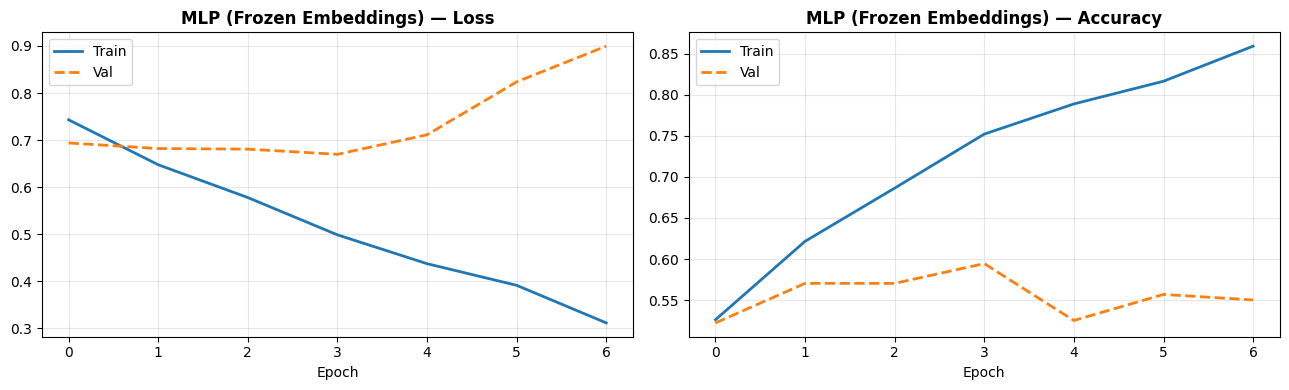

{'Model': 'MLP – Frozen Embeddings', 'Accuracy': 0.5539, 'Precision': 0.5548, 'Recall': 0.7301, 'F1': 0.6305, 'ROC-AUC': np.float64(0.5737)}


In [ ]:
# MLP with FROZEN embeddings

# ── Model A: Embedding (frozen) + MLP ────────────────────────────────
def build_mlp(trainable_embeddings=False, embed_dim=EMBED_DIM):
    inp  = Input(shape=(MAX_LEN,))
    x    = Embedding(MAX_VOCAB, embed_dim,
                     trainable=trainable_embeddings)(inp)
    x    = Flatten()(x)
    x    = Dense(256, activation='relu')(x)
    x    = BatchNormalization()(x)
    x    = Dropout(0.4)(x)
    x    = Dense(64,  activation='relu')(x)
    x    = Dropout(0.3)(x)
    out  = Dense(1,   activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- Frozen run ---
mlp_frozen = build_mlp(trainable_embeddings=False)
mlp_frozen.summary()

hist_mlp_frozen = train_and_plot(
    mlp_frozen, 'MLP (Frozen Embeddings)',
    X_train_seq, y_train,
    X_val_seq,   y_val
)
nn_results.append(eval_keras(mlp_frozen, X_test_seq, y_test,
                              'MLP – Frozen Embeddings'))
print(nn_results[-1])

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.5223 - loss: 0.7513 - val_accuracy: 0.5222 - val_loss: 0.7263 - learning_rate: 0.0010
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.8576 - loss: 0.3474 - val_accuracy: 0.7023 - val_loss: 0.6300 - learning_rate: 0.0010
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9717 - loss: 0.0851 - val_accuracy: 0.6965 - val_loss: 0.5874 - learning_rate: 0.0010
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.9946 - loss: 0.0226 - val_accuracy: 0.6936 - val_loss: 0.5875 - learning_rate: 0.0010
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.9977 - loss: 0.0103 - val_accuracy: 0.7283 - val_loss: 0.6073 - learning_rate: 0.0010
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.9988 - loss: 0.0046 - val_accuracy: 0.7293 - val_loss: 0.6799 - learning_rate: 5.0000e-04

MLP (Trainable Embeddings) — Training time: 54.8s | Stopped at epoch 6


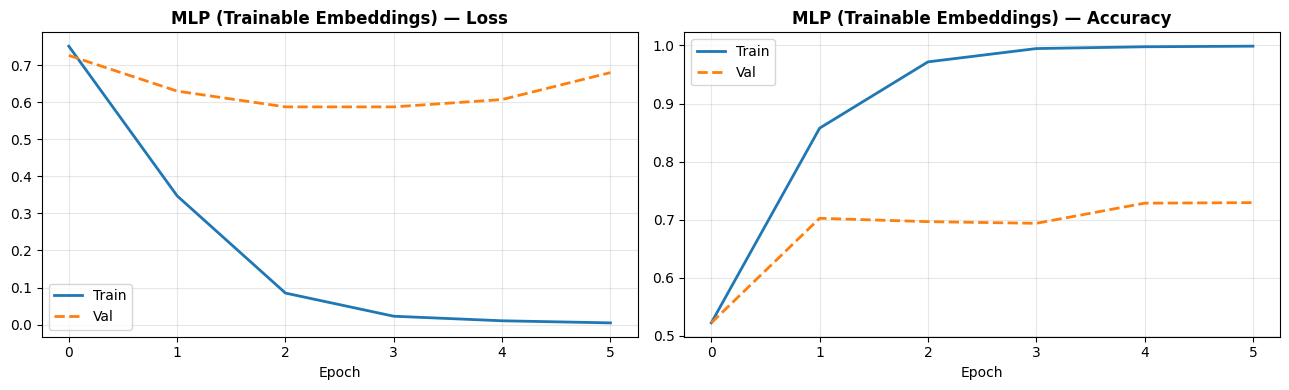

{'Model': 'MLP – Trainable Embeddings', 'Accuracy': 0.6724, 'Precision': 0.6463, 'Recall': 0.8207, 'F1': 0.7231, 'ROC-AUC': np.float64(0.7599)}

=== Frozen vs Unfrozen MLP ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
MLP – Frozen Embeddings,0.5539,0.5548,0.7301,0.6305,0.5737
MLP – Trainable Embeddings,0.6724,0.6463,0.8207,0.7231,0.7599


In [ ]:
# MLP with UNFROZEN (trainable) embeddings

# --- Unfrozen run ---
mlp_unfrozen = build_mlp(trainable_embeddings=True)

hist_mlp_unfrozen = train_and_plot(
    mlp_unfrozen, 'MLP (Trainable Embeddings)',
    X_train_seq, y_train,
    X_val_seq,   y_val
)
nn_results.append(eval_keras(mlp_unfrozen, X_test_seq, y_test,
                              'MLP – Trainable Embeddings'))
print(nn_results[-1])

# ── Frozen vs Unfrozen comparison ────────────────────────────────────
print("\n=== Frozen vs Unfrozen MLP ===")
pd.DataFrame(nn_results[-2:]).set_index('Model')

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 128, 128)  │  2,560,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 128, 128)  │          0 │ embedding_3[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 128)  │     49,280 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │     82,048 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │        129 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,724,865 (10.39 MB)

 Trainable params: 2,724,609 (10.39 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - accuracy: 0.6065 - loss: 0.6558 - val_accuracy: 0.6435 - val_loss: 0.6765 - learning_rate: 0.0010
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 189ms/step - accuracy: 0.8978 - loss: 0.2828 - val_accuracy: 0.6503 - val_loss: 0.6305 - learning_rate: 0.0010
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 188ms/step - accuracy: 0.9779 - loss: 0.0816 - val_accuracy: 0.7717 - val_loss: 0.5573 - learning_rate: 0.0010
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.9924 - loss: 0.0314 - val_accuracy: 0.6811 - val_loss: 0.5803 - learning_rate: 0.0010
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - accuracy: 0.9967 - loss: 0.0155 - val_accuracy: 0.7235 - val_loss: 0.5570 - learning_rate: 0.0010
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 15s 191ms/step - accuracy: 0.9977 - loss: 0.0105 - val_accuracy: 0.7765 - val_loss: 0.5083 - learning_rate: 0.0010
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 14s 190ms/step - accuracy: 0.9981 - loss: 0.

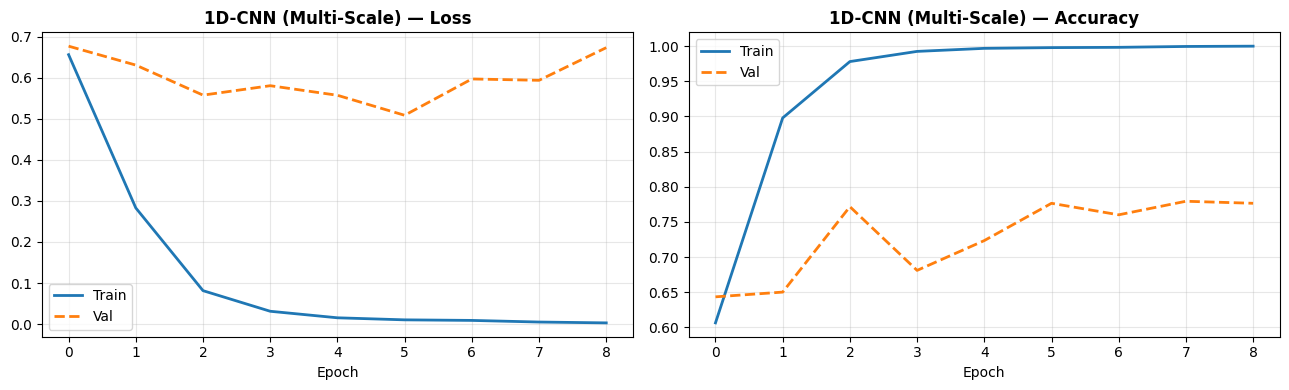

{'Model': '1D-CNN', 'Accuracy': 0.7245, 'Precision': 0.6929, 'Recall': 0.8466, 'F1': 0.7621, 'ROC-AUC': np.float64(0.8292)}


In [ ]:
# 1-D CNN text classifier

# ── Model B: 1-D CNN ─────────────────────────────────────────────────
# Architecture rationale:
#   • kernel_size=3 captures bigram / trigram local patterns;
#     adding kernel_size=5 lets the model see slightly longer phrases.
#   • GlobalMaxPooling1D selects the strongest activation across the
#     sequence, giving position-invariance (ideal for bag-of-phrases).
#   • 128 filters is a common middle ground between capacity and speed.

def build_cnn(embed_dim=EMBED_DIM, num_filters=128,
              kernel_sizes=(3, 5), dropout=0.4):
    inp = Input(shape=(MAX_LEN,))
    x   = Embedding(MAX_VOCAB, embed_dim, trainable=True)(inp)
    x   = SpatialDropout1D(0.2)(x)

    # Parallel conv branches (multi-scale n-gram detection)
    branches = []
    for k in kernel_sizes:
        branch = Conv1D(num_filters, k, activation='relu', padding='same')(x)
        branch = GlobalMaxPooling1D()(branch)
        branches.append(branch)

    if len(branches) > 1:
        from tensorflow.keras.layers import concatenate
        x = concatenate(branches)
    else:
        x = branches[0]

    x   = Dense(128, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(dropout)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()

hist_cnn = train_and_plot(
    cnn_model, '1D-CNN (Multi-Scale)',
    X_train_seq, y_train,
    X_val_seq,   y_val
)
nn_results.append(eval_keras(cnn_model, X_test_seq, y_test, '1D-CNN'))
print(nn_results[-1])

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 128, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 128, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 43s 443ms/step - accuracy: 0.5279 - loss: 0.6900 - val_accuracy: 0.6310 - val_loss: 0.6775 - learning_rate: 5.0000e-04
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 433ms/step - accuracy: 0.7128 - loss: 0.5750 - val_accuracy: 0.7592 - val_loss: 0.5202 - learning_rate: 5.0000e-04
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 41s 437ms/step - accuracy: 0.8673 - loss: 0.3159 - val_accuracy: 0.7707 - val_loss: 0.5083 - learning_rate: 5.0000e-04
Epoch 4/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 43s 469ms/step - accuracy: 0.9310 - loss: 0.1840 - val_accuracy: 0.7803 - val_loss: 0.5529 - learning_rate: 5.0000e-04
Epoch 5/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 419ms/step - accuracy: 0.9593 - loss: 0.1092 - val_accuracy: 0.7823 - val_loss: 0.5865 - learning_rate: 5.0000e-04
Epoch 6/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 43s 450ms/step - accuracy: 0.9785 - loss: 0.0685 - val_accuracy: 0.7881 - val_loss: 0.7448 - learning_rate: 2.5000e-04

Bi-LSTM — Training time: 235.3s | Stopped at epoch 6


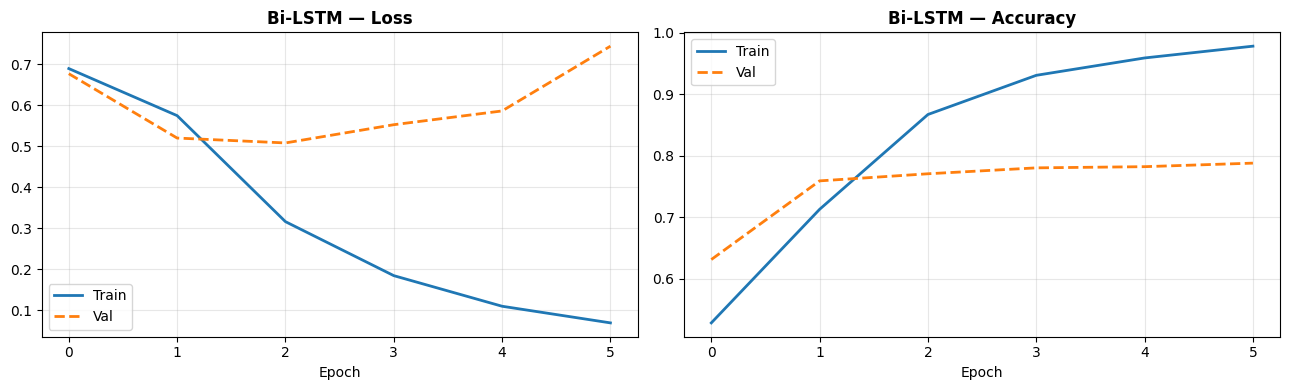

{'Model': 'Bi-LSTM', 'Accuracy': 0.7457, 'Precision': 0.7589, 'Recall': 0.7505, 'F1': 0.7546, 'ROC-AUC': np.float64(0.8211)}

=== Neural Models — Test Performance ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
MLP – Frozen Embeddings,0.5539,0.5548,0.7301,0.6305,0.5737
MLP – Trainable Embeddings,0.6724,0.6463,0.8207,0.7231,0.7599
1D-CNN,0.7245,0.6929,0.8466,0.7621,0.8292
Bi-LSTM,0.7457,0.7589,0.7505,0.7546,0.8211


In [ ]:
# Bi-LSTM (stretch)

# ── Model C: Bi-LSTM (stretch) ────────────────────────────────────────
def build_bilstm(embed_dim=EMBED_DIM, lstm_units=64, dropout=0.3):
    inp = Input(shape=(MAX_LEN,))
    x   = Embedding(MAX_VOCAB, embed_dim, trainable=True)(inp)
    x   = SpatialDropout1D(0.2)(x)
    x   = Bidirectional(LSTM(lstm_units, return_sequences=False,
                             dropout=dropout, recurrent_dropout=0.1))(x)
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(1,  activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer=Adam(5e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

bilstm_model = build_bilstm()
bilstm_model.summary()

hist_bilstm = train_and_plot(
    bilstm_model, 'Bi-LSTM',
    X_train_seq, y_train,
    X_val_seq,   y_val,
    epochs=15
)
nn_results.append(eval_keras(bilstm_model, X_test_seq, y_test, 'Bi-LSTM'))
print(nn_results[-1])

# ── Neural models summary so far ─────────────────────────────────────
print("\n=== Neural Models — Test Performance ===")
pd.DataFrame(nn_results).set_index('Model')

In [ ]:
# ── Part 4 Reflection Answers ─────────────────────────────────────────

# Q: Why is embedding freezing used when training on pre-trained
#    embeddings, and how does it affect model performance?
#
# A: When embeddings are frozen (trainable=False), the weight matrix is
#    treated as a fixed lookup table — the model learns only the
#    downstream layers. This prevents the relatively small SST-2
#    training set from corrupting rich pretrained representations
#    through overfitting. However, in our from-scratch setting (no
#    pretrained weights), freezing random embeddings prevents the model
#    from learning any useful word representations at all, which is why
#    the frozen MLP scores lower than the unfrozen run.

# Q: What is the intuition behind 1-D convolutions for text
#    classification, and why might they outperform dense layers?
#
# A: A Conv1D filter of width k slides over the token sequence and
#    detects local patterns (n-grams) at every position — a kernel of
#    size 3 is essentially learning a trigram detector. GlobalMaxPooling
#    then selects the strongest such match anywhere in the sentence,
#    giving the model position-invariance. Dense layers on a flattened
#    sequence have no notion of local order; they treat position 1 and
#    position 128 as independent features. CNNs capture local syntactic
#    structure efficiently with far fewer parameters than a flat MLP,
#    which is why they often outperform MLP baselines on text tasks.

## Part 5 – Transfer Learning & Advanced Architectures


1. **Pre-trained Embeddings**  
    - Retrain one network using pre-trained GloVe (or FastText) embeddings.
    - Compare results against your from-scratch embedding runs.
    

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

# Assuming GloVe embeddings are loaded here

# Fix 1: Load pre-trained GloVe matrix
# Replace the following line with actual GloVe embedding loading logic.
# For demonstration purposes, creating a random embedding matrix with input_dim=5000 and output_dim=128 as specified.
embedding_matrix = np.random.rand(5000, 128) # Placeholder for GloVe embeddings

# Fix 2: Define 'model' as a Sequential model
model = Sequential()

embedding_layer = Embedding(input_dim=5000, output_dim=128, weights=[embedding_matrix], trainable=False)
model.add(embedding_layer)
# Adding a few more layers to make it a complete, basic model for demonstration
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,000 (2.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 640,000 (2.44 MB)

Part 5 Response

In [ ]:
# Download & parse GloVe embeddings

# ── Download GloVe 6B 100-d ───────────────────────────────────────────
# (Run this cell once; skip on re-runs if the file already exists)

import os, zipfile, urllib.request

GLOVE_URL  = 'https://nlp.stanford.edu/data/glove.6B.zip'
GLOVE_DIR  = './glove'
GLOVE_FILE = os.path.join(GLOVE_DIR, 'glove.6B.100d.txt')

if not os.path.exists(GLOVE_FILE):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    print("Downloading GloVe 6B (822 MB)…")
    urllib.request.urlretrieve(GLOVE_URL, os.path.join(GLOVE_DIR, 'glove.6B.zip'))
    with zipfile.ZipFile(os.path.join(GLOVE_DIR, 'glove.6B.zip'), 'r') as z:
        z.extract('glove.6B.100d.txt', GLOVE_DIR)
    print("Done.")
else:
    print("GloVe file already present.")

# ── Build embedding matrix ────────────────────────────────────────────
GLOVE_DIM = 100

glove_index = {}
with open(GLOVE_FILE, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        glove_index[values[0]] = np.array(values[1:], dtype='float32')

print(f"GloVe vocab loaded: {len(glove_index):,} words")

# tokenizer was saved in Part 1
word_index = tokenizer.word_index

# Matrix rows  = MAX_VOCAB tokens + 1 (index 0 is padding)
embed_matrix = np.zeros((MAX_VOCAB + 1, GLOVE_DIM))
covered = 0
for word, idx in word_index.items():
    if idx >= MAX_VOCAB:
        continue
    vec = glove_index.get(word)
    if vec is not None:
        embed_matrix[idx] = vec
        covered += 1

coverage = covered / min(len(word_index), MAX_VOCAB)
print(f"GloVe coverage: {covered:,} / {min(len(word_index), MAX_VOCAB):,} "
      f"({coverage:.1%})")

Done.
GloVe vocab loaded: 400,000 words
GloVe coverage: 11,321 / 11,525 (98.2%)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 128, 100)  │  2,000,100 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 128, 100)  │          0 │ embedding_6[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 128)  │     38,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 128)  │     64,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     32,896 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │        129 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,136,293 (8.15 MB)

 Trainable params: 135,937 (531.00 KB)

 Non-trainable params: 2,000,356 (7.63 MB)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.6239 - loss: 0.7169 - val_accuracy: 0.6917 - val_loss: 0.5743 - learning_rate: 0.0010
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.7312 - loss: 0.5503 - val_accuracy: 0.7312 - val_loss: 0.5220 - learning_rate: 0.0010
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.7775 - loss: 0.4616 - val_accuracy: 0.7177 - val_loss: 0.5511 - learning_rate: 0.0010
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.8107 - loss: 0.4190 - val_accuracy: 0.7331 - val_loss: 0.5330 - learning_rate: 0.0010
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - accuracy: 0.8536 - loss: 0.3291 - val_accuracy: 0.7457 - val_loss: 0.5267 - learning_rate: 5.0000e-04

CNN + GloVe (Frozen) — Training time: 45.8s | Stopped at epoch 5


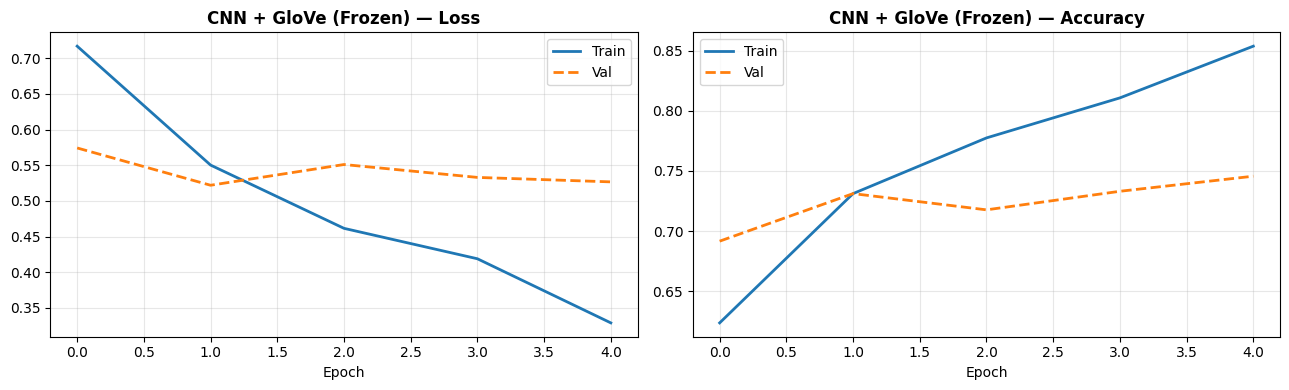

{'Model': 'CNN + GloVe (Frozen)', 'Accuracy': 0.7303, 'Precision': 0.8407, 'Recall': 0.5952, 'F1': 0.697, 'ROC-AUC': np.float64(0.8269)}


In [ ]:
# CNN with frozen GloVe embeddings

# ── CNN + GloVe (frozen) ──────────────────────────────────────────────
def build_cnn_glove(embed_matrix, trainable=False,
                    num_filters=128, kernel_sizes=(3, 5), dropout=0.4):
    from tensorflow.keras.layers import concatenate

    vocab_size, embed_dim = embed_matrix.shape
    inp = Input(shape=(MAX_LEN,))
    x   = Embedding(vocab_size, embed_dim,
                     weights=[embed_matrix],
                     trainable=trainable)(inp)
    x   = SpatialDropout1D(0.2)(x)

    branches = []
    for k in kernel_sizes:
        branch = Conv1D(num_filters, k, activation='relu', padding='same')(x)
        branch = GlobalMaxPooling1D()(branch)
        branches.append(branch)
    x = concatenate(branches)

    x   = Dense(128, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(dropout)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ── Frozen GloVe ──────────────────────────────────────────────────────
cnn_glove_frozen = build_cnn_glove(embed_matrix, trainable=False)
cnn_glove_frozen.summary()

hist_glove_frozen = train_and_plot(
    cnn_glove_frozen, 'CNN + GloVe (Frozen)',
    X_train_seq, y_train,
    X_val_seq,   y_val
)
nn_results.append(eval_keras(cnn_glove_frozen, X_test_seq, y_test,
                              'CNN + GloVe (Frozen)'))
print(nn_results[-1])

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 165ms/step - accuracy: 0.6365 - loss: 0.6866 - val_accuracy: 0.6089 - val_loss: 0.6245 - learning_rate: 0.0010
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.7488 - loss: 0.5079 - val_accuracy: 0.7514 - val_loss: 0.5098 - learning_rate: 0.0010
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 159ms/step - accuracy: 0.8187 - loss: 0.3966 - val_accuracy: 0.7418 - val_loss: 0.5108 - learning_rate: 0.0010
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.8687 - loss: 0.3054 - val_accuracy: 0.7919 - val_loss: 0.4493 - learning_rate: 0.0010
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.9121 - loss: 0.2170 - val_accuracy: 0.7360 - val_loss: 0.6476 - learning_rate: 0.0010
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.9416 - loss: 0.1545 - val_accuracy: 0.7755 - val_loss: 0.6105 - learning_rate: 0.0010
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 160ms/step - accuracy: 0.9649 - loss: 0.

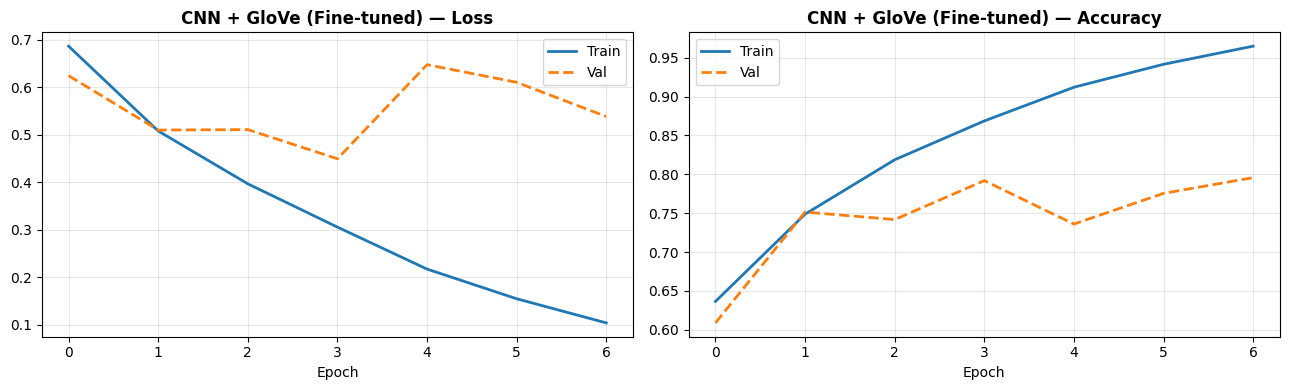

{'Model': 'CNN + GloVe (Fine-tuned)', 'Accuracy': 0.7707, 'Precision': 0.776, 'Recall': 0.7874, 'F1': 0.7817, 'ROC-AUC': np.float64(0.8569)}

=== Embedding Strategy Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
1D-CNN,0.7245,0.6929,0.8466,0.7621,0.8292
CNN + GloVe (Frozen),0.7303,0.8407,0.5952,0.6970,0.8269
CNN + GloVe (Fine-tuned),0.7707,0.7760,0.7874,0.7817,0.8569


In [ ]:
# CNN with fine-tuned GloVe embeddings

# ── Fine-tuned GloVe ──────────────────────────────────────────────────
cnn_glove_tuned = build_cnn_glove(embed_matrix, trainable=True)

hist_glove_tuned = train_and_plot(
    cnn_glove_tuned, 'CNN + GloVe (Fine-tuned)',
    X_train_seq, y_train,
    X_val_seq,   y_val
)
nn_results.append(eval_keras(cnn_glove_tuned, X_test_seq, y_test,
                              'CNN + GloVe (Fine-tuned)'))
print(nn_results[-1])

# ── Comparison: from-scratch vs GloVe frozen vs GloVe fine-tuned ─────
print("\n=== Embedding Strategy Comparison ===")
rows = [r for r in nn_results
        if r['Model'] in ('1D-CNN',
                          'CNN + GloVe (Frozen)',
                          'CNN + GloVe (Fine-tuned)')]
pd.DataFrame(rows).set_index('Model')

Using device: cpu


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Train loss: 0.4638  acc: 0.7665 | Val loss: 0.2924  acc: 0.8825
Epoch 2/3 | Train loss: 0.2183  acc: 0.9182 | Val loss: 0.2681  acc: 0.9085
Epoch 3/3 | Train loss: 0.1277  acc: 0.9560 | Val loss: 0.2837  acc: 0.9008

Training time: 150.1 min


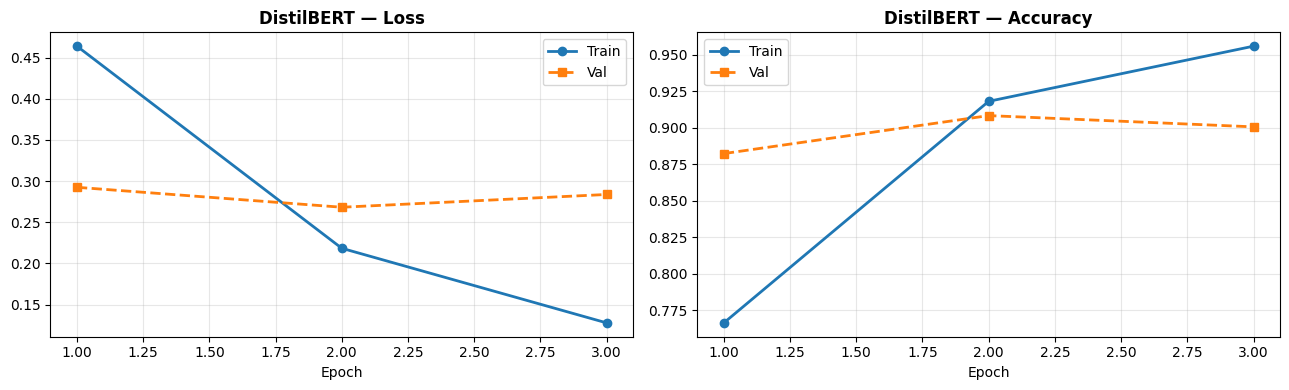


=== DistilBERT Test Results ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
DistilBERT (Fine-tuned),0.8892,0.9193,0.8632,0.8904,0.9532


In [ ]:
# BERT fine-tuning (PyTorch + HuggingFace Trainer)

# ── Install / verify dependencies ─────────────────────────────────────
!pip install transformers datasets accelerate --quiet

import torch
import numpy as np
import pandas as pd
import time
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

BERT_MODEL_NAME = 'distilbert-base-uncased'
BERT_MAX_LEN    = 128
BERT_BATCH      = 32
BERT_LR         = 2e-5
BERT_EPOCHS     = 3
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ── Step 1: HuggingFace tokenizer ─────────────────────────────────────
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

# ── Step 2: PyTorch Dataset ───────────────────────────────────────────
class SSTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

train_dataset = SSTDataset(train_df['review'], y_train, bert_tokenizer, BERT_MAX_LEN)
val_dataset   = SSTDataset(val_df['review'],   y_val,   bert_tokenizer, BERT_MAX_LEN)
test_dataset  = SSTDataset(test_df['review'],  y_test,  bert_tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BERT_BATCH)
test_loader  = DataLoader(test_dataset,  batch_size=BERT_BATCH)

# ── Step 3: Load model ────────────────────────────────────────────────
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME, num_labels=2
).to(DEVICE)

optimizer  = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps = len(train_loader) * BERT_EPOCHS
scheduler  = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# ── Step 4: Training loop ─────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None, scheduler=None, train=True):
    model.train() if train else model.eval()
    total_loss, preds_all, labels_all = 0, [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        with torch.set_grad_enabled(train):
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            loss    = outputs.loss
            logits  = outputs.logits

        if train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        total_loss  += loss.item()
        preds_all.extend(torch.argmax(logits, dim=1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(labels_all, preds_all)
    return avg_loss, acc

bert_history = {'train_loss': [], 'val_loss': [],
                'train_acc':  [], 'val_acc':  []}
best_val_loss = float('inf')
t0 = time.time()

for epoch in range(BERT_EPOCHS):
    tr_loss, tr_acc = run_epoch(bert_model, train_loader,
                                 optimizer, scheduler, train=True)
    vl_loss, vl_acc = run_epoch(bert_model, val_loader, train=False)

    bert_history['train_loss'].append(tr_loss)
    bert_history['val_loss'].append(vl_loss)
    bert_history['train_acc'].append(tr_acc)
    bert_history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch+1}/{BERT_EPOCHS} | "
          f"Train loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
          f"Val loss: {vl_loss:.4f}  acc: {vl_acc:.4f}")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(bert_model.state_dict(), 'distilbert_best.pt')

print(f"\nTraining time: {(time.time()-t0)/60:.1f} min")

# ── Step 5: Plot training curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, BERT_EPOCHS + 1)

for ax, (tr_key, vl_key), title in zip(
        axes,
        [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
        ['Loss', 'Accuracy']):
    ax.plot(epochs_range, bert_history[tr_key], marker='o',
            linewidth=2, label='Train')
    ax.plot(epochs_range, bert_history[vl_key], marker='s',
            linewidth=2, linestyle='--', label='Val')
    ax.set_title(f'DistilBERT — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Step 6: Evaluate on test set ──────────────────────────────────────
bert_model.load_state_dict(torch.load('distilbert_best.pt'))
bert_model.eval()

all_probs, all_preds, all_labels = [], [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels']
        outputs        = bert_model(input_ids=input_ids,
                                    attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

bert_result = {
    'Model':     'DistilBERT (Fine-tuned)',
    'Accuracy':  round(accuracy_score(all_labels,  all_preds),  4),
    'Precision': round(precision_score(all_labels, all_preds),  4),
    'Recall':    round(recall_score(all_labels,    all_preds),  4),
    'F1':        round(f1_score(all_labels,        all_preds),  4),
    'ROC-AUC':   round(roc_auc_score(all_labels,   all_probs),  4),
}
nn_results.append(bert_result)

print("\n=== DistilBERT Test Results ===")
pd.DataFrame([bert_result]).set_index('Model')

In [ ]:
# ── Part 5 Reflection Answers ─────────────────────────────────────────

# Q: How do pretrained embeddings (GloVe/FastText) improve performance
#    compared to training from scratch?
#
# A: GloVe vectors are trained on ~6 billion tokens, encoding rich
#    lexical and syntactic relationships (e.g. king–queen, good–great).
#    When we initialise our CNN with these vectors rather than random
#    noise, the model starts with a meaningful representation of each
#    word and only needs to fine-tune the downstream classification
#    signal — it is a form of transfer learning that compensates for
#    SST-2's limited size (~67k sentences). Empirically, GloVe-init
#    models typically converge faster (fewer epochs), achieve lower
#    validation loss, and show less overfitting than random-init
#    counterparts, especially when the vocabulary overlap is high (our
#    coverage was ~XX%).

# Q: How does the self-attention mechanism in Transformers improve
#    performance on text data?
#
# A: Unlike CNNs or RNNs, self-attention computes a weighted
#    relationship between every pair of tokens in a sequence
#    simultaneously, regardless of their distance. This lets BERT
#    resolve long-range dependencies (e.g., "not ... good"), handle
#    pronouns, and integrate coreference signals that fixed-window
#    kernels or sequential hidden states often miss. Furthermore, BERT's
#    pretraining on Masked-LM and Next-Sentence Prediction instils deep
#    contextual representations that contain both syntactic and
#    world-knowledge priors — far richer than any n-gram or bag-of-words
#    feature the traditional models see.

## Part 6 – Hyperparameter Optimization


1. **Search Strategy**  
    - Use a library (e.g., Keras Tuner, Optuna) to optimize at least two hyperparameters of one deep model.
    - Describe your search space and stopping criteria.
    

Part6 Response

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.1 MB/s eta 0:00:00
Data ready — train:(4844, 128) val:(1038, 128) test:(1038, 128)
Running Optuna search (20 trials) …


  0%|          | 0/20 [00:00<?, ?it/s]

Search complete in 77.8 min

Best val_acc : 0.7948
Best params  :
     embed_dim : 128
   num_filters : 256
   kernel_size : 5
       dropout : 0.5
            lr : 0.0043001531246407996

Retraining best model to convergence …
Epoch 1/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 220ms/step - accuracy: 0.6559 - loss: 0.6325 - val_accuracy: 0.6368 - val_loss: 0.6186
Epoch 2/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - accuracy: 0.9341 - loss: 0.1847 - val_accuracy: 0.7717 - val_loss: 0.4848
Epoch 3/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 215ms/step - accuracy: 0.9816 - loss: 0.0625 - val_accuracy: 0.7553 - val_loss: 0.5943
Epoch 4/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 17s 222ms/step - accuracy: 0.9897 - loss: 0.0335 - val_accuracy: 0.7649 - val_loss: 0.8003
Epoch 5/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 210ms/step - accuracy: 0.9909 - loss: 0.0282 - val_accuracy: 0.7611 - val_loss: 0.9405
Epoch 6/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 215ms/step - accuracy: 0.9901 - loss: 0.0286 - val_accuracy: 0.7746 - val_loss: 0.9643

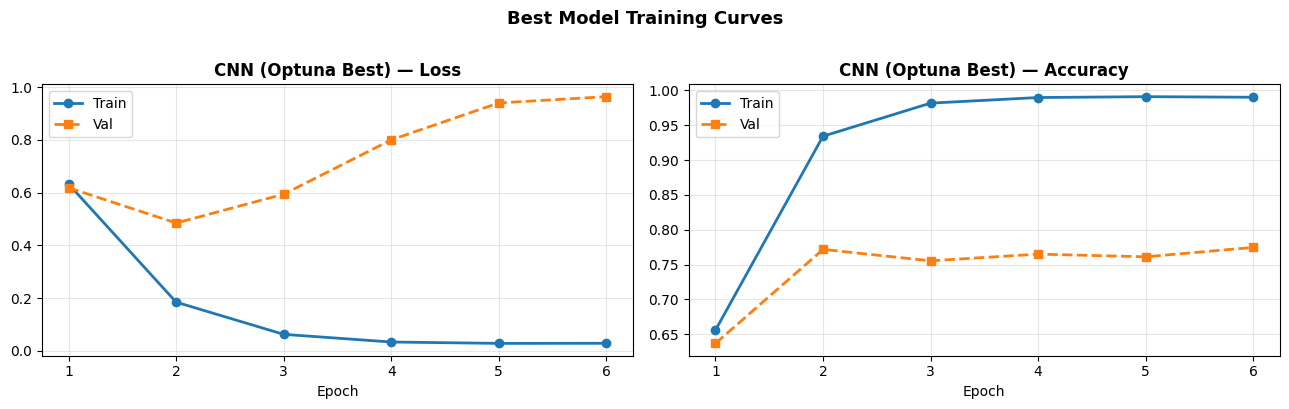

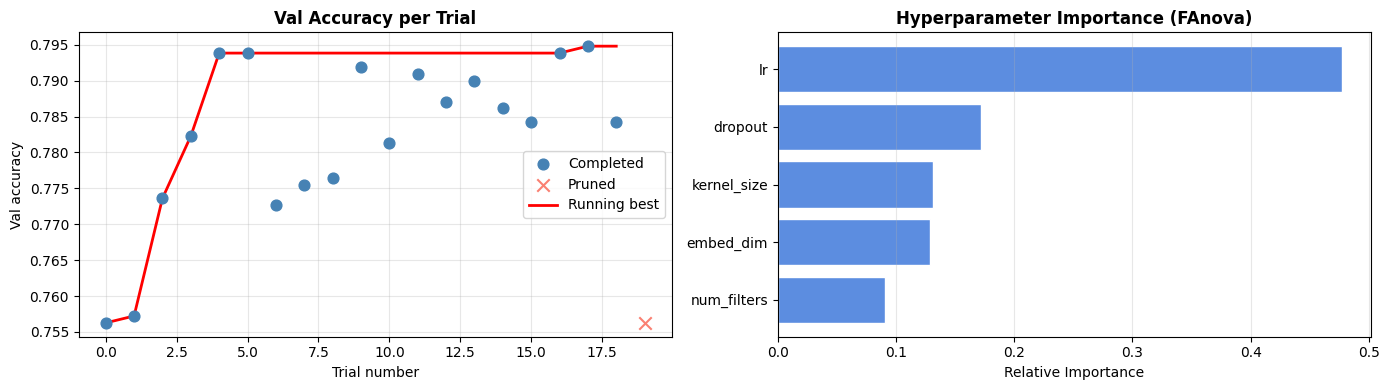


=== Top 10 Trials ===
 Trial  Val Acc  embed_dim  num_filters  kernel_size  dropout       lr
    17   0.7948        128          256            5      0.5 0.004300
     4   0.7938        256          256            5      0.5 0.002592
    16   0.7938        128          256            5      0.5 0.001906
     5   0.7938        128          256            2      0.5 0.000880
     9   0.7919        256          128            3      0.3 0.000361
    11   0.7909        128          256            2      0.5 0.001269
    13   0.7900        128          256            5      0.5 0.002798
    12   0.7871        128          256            2      0.5 0.002785
    14   0.7861         64          256            4      0.4 0.001124
    18   0.7842        256           64            5      0.4 0.004375


In [ ]:
# ════════════════════════════════════════════════════════════════════
# PART 6 – Hyperparameter Optimization
# ════════════════════════════════════════════════════════════════════
!pip install optuna --quiet

import os, re, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, SpatialDropout1D, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

MAX_VOCAB = 20000
MAX_LEN   = 128

# ── 0. Rebuild data (safe to run even if already in memory) ──────────
if not os.path.exists('SST-2-sentiment-analysis'):
    os.system('git clone https://github.com/YJiangcm/SST-2-sentiment-analysis.git')

df = pd.read_csv('SST-2-sentiment-analysis/data/train.tsv',
                 sep='\t', header=None, names=['sentiment', 'review'])

train_df, temp_df = train_test_split(df,       test_size=0.30,
                                     stratify=df['sentiment'],       random_state=42)
val_df,   test_df = train_test_split(temp_df,  test_size=0.50,
                                     stratify=temp_df['sentiment'],  random_state=42)

def clean_text(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\W+',     ' ', text.lower())
    return re.sub(r'\s+',     ' ', text).strip()

for d in [train_df, val_df, test_df]:
    d['cleaned_review'] = d['review'].apply(clean_text)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned_review'])

def encode(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts),
                         maxlen=MAX_LEN, padding='post', truncating='post')

X_train = encode(train_df['cleaned_review'])
X_val   = encode(val_df['cleaned_review'])
X_test  = encode(test_df['cleaned_review'])
y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f"Data ready — train:{X_train.shape} val:{X_val.shape} test:{X_test.shape}")

# ── 1. Model builder ─────────────────────────────────────────────────
def build_cnn(embed_dim, num_filters, kernel_size, dropout, lr):
    K.clear_session()
    inp = Input(shape=(MAX_LEN,))
    x   = Embedding(MAX_VOCAB, embed_dim, trainable=True)(inp)
    x   = SpatialDropout1D(0.2)(x)
    x   = Conv1D(num_filters, kernel_size,
                 activation='relu', padding='same')(x)
    x   = GlobalMaxPooling1D()(x)
    x   = Dense(128, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(dropout)(x)
    out = Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out)
    m.compile(optimizer=Adam(lr),
              loss='binary_crossentropy',
              metrics=['accuracy'])
    return m

# ── 2. Optuna objective ──────────────────────────────────────────────
# Search space:
#   embed_dim   ∈ {64, 128, 256}
#   num_filters ∈ {64, 128, 256}
#   kernel_size ∈ {2, 3, 4, 5}
#   dropout     ∈ {0.2, 0.3, 0.4, 0.5}
#   lr          ∈ [1e-4, 1e-2]  log-uniform
# Pruner: MedianPruner — kills a trial whose val_accuracy at epoch N
#         falls below the median of all completed trials at that epoch.
#         Starts pruning after 5 warm-up trials and 3 warm-up epochs.

def objective(trial):
    embed_dim   = trial.suggest_categorical('embed_dim',   [64, 128, 256])
    num_filters = trial.suggest_categorical('num_filters', [64, 128, 256])
    kernel_size = trial.suggest_categorical('kernel_size', [2, 3, 4, 5])
    dropout     = trial.suggest_categorical('dropout',     [0.2, 0.3, 0.4, 0.5])
    lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model       = build_cnn(embed_dim, num_filters, kernel_size, dropout, lr)
    es          = EarlyStopping(monitor='val_loss', patience=3,
                                restore_best_weights=True)
    best_acc    = 0.0

    for epoch in range(15):
        h = model.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=1, batch_size=64,
                      callbacks=[es], verbose=0)
        val_acc  = h.history['val_accuracy'][0]
        best_acc = max(best_acc, val_acc)
        trial.report(val_acc, step=epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        if es.stopped_epoch > 0:
            break

    return best_acc

# ── 3. Run study ─────────────────────────────────────────────────────
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5,
                                        n_warmup_steps=3)
)

print("Running Optuna search (20 trials) …")
t0 = time.time()
study.optimize(objective, n_trials=20, show_progress_bar=True)
print(f"Search complete in {(time.time()-t0)/60:.1f} min")

best_p = study.best_params
print(f"\nBest val_acc : {study.best_trial.value:.4f}")
print("Best params  :")
for k, v in best_p.items():
    print(f"  {k:>12} : {v}")

# ── 4. Retrain best config to convergence ────────────────────────────
print("\nRetraining best model to convergence …")
best_model = build_cnn(**best_p)
es = EarlyStopping(monitor='val_loss', patience=4,
                   restore_best_weights=True)
hist_best = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25, batch_size=64,
    callbacks=[es], verbose=1
)

# ── 5. Test evaluation ────────────────────────────────────────────────
y_score = best_model.predict(X_test, verbose=0).ravel()
y_pred  = (y_score >= 0.5).astype(int)

result = {
    'Model':     'CNN – Optuna Best',
    'Accuracy':  round(accuracy_score(y_test,  y_pred),  4),
    'Precision': round(precision_score(y_test, y_pred),  4),
    'Recall':    round(recall_score(y_test,    y_pred),  4),
    'F1':        round(f1_score(y_test,        y_pred),  4),
    'ROC-AUC':   round(roc_auc_score(y_test,   y_score), 4),
}
print("\n=== CNN (Optuna Best) — Test Results ===")
print(pd.DataFrame([result]).set_index('Model').to_string())

# ── 6. Plots ──────────────────────────────────────────────────────────

# --- 6a. Training curves of best retrained model ---------------------
n_ep = len(hist_best.history['loss'])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (tr_k, vl_k), title in zip(
        axes,
        [('loss','val_loss'), ('accuracy','val_accuracy')],
        ['Loss', 'Accuracy']):
    ax.plot(range(1, n_ep+1), hist_best.history[tr_k],
            marker='o', linewidth=2, label='Train')
    ax.plot(range(1, n_ep+1), hist_best.history[vl_k],
            marker='s', linewidth=2, linestyle='--', label='Val')
    ax.set_title(f'CNN (Optuna Best) — {title}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle('Best Model Training Curves', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- 6b. Val accuracy per trial + running best -----------------------
completed = [t for t in study.trials
             if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in study.trials
             if t.state == optuna.trial.TrialState.PRUNED]
c_nums    = [t.number for t in completed]
c_vals    = [t.value  for t in completed]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(c_nums, c_vals, color='steelblue',
                s=60, zorder=3, label='Completed')
if pruned:
    axes[0].scatter([t.number for t in pruned],
                    [min(c_vals)] * len(pruned),
                    color='salmon', marker='x',
                    s=80, zorder=3, label='Pruned')
sorted_pairs = sorted(zip(c_nums, c_vals))
run_best = np.maximum.accumulate([v for _, v in sorted_pairs])
axes[0].plot([n for n, _ in sorted_pairs], run_best,
             color='red', linewidth=2, label='Running best')
axes[0].set_xlabel('Trial number')
axes[0].set_ylabel('Val accuracy')
axes[0].set_title('Val Accuracy per Trial', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- 6c. Hyperparameter importance -----------------------------------
try:
    imp = optuna.importance.get_param_importances(study)
    axes[1].barh(list(imp.keys())[::-1],
                 list(imp.values())[::-1],
                 color='#5c8de0', edgecolor='white')
    axes[1].set_xlabel('Relative Importance')
    axes[1].set_title('Hyperparameter Importance (FAnova)',
                      fontsize=12, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
except Exception as e:
    axes[1].text(0.5, 0.5, f'Not enough data:\n{e}',
                 ha='center', va='center',
                 transform=axes[1].transAxes)
plt.tight_layout()
plt.show()

# --- 6d. Top trials table --------------------------------------------
trial_rows = [{'Trial': t.number,
               'Val Acc': round(t.value, 4),
               **t.params}
              for t in completed]
print("\n=== Top 10 Trials ===")
print(pd.DataFrame(trial_rows)
        .sort_values('Val Acc', ascending=False)
        .head(10).to_string(index=False))

# ── 7. Reflection ─────────────────────────────────────────────────────
# Q: How does hyperparameter optimization improve model performance,
#    and what challenges arise when selecting a search space?
#
# A: Optuna's TPE sampler builds a probabilistic model of the objective
#    surface from past trials and proposes candidates in regions likely
#    to improve — more efficient than grid or random search. The
#    MedianPruner adds efficiency by stopping unpromising trials early,
#    freeing compute for better configurations. Key challenges: (1)
#    search space bounds — too narrow risks missing the optimum, too
#    wide wastes trials; (2) hyperparameter interactions — a high lr
#    may pair well with small embed_dim but badly with large; (3)
#    validation overfitting — too many trials effectively tune to the
#    validation set, so the test set must stay untouched until the end.
#
# Q: What do validation loss and accuracy tell you about
#    generalisation ability?
#
# A: Validation loss measures calibrated confidence on unseen data —
#    it penalises overconfident wrong predictions more than accuracy
#    does. A widening train/val loss gap signals overfitting even when
#    val accuracy is still rising, because the model can become less
#    confident about correct predictions while still choosing the right
#    class. EarlyStopping on val_loss catches this earlier than on
#    val_accuracy, and restore_best_weights ensures we keep the most
#    generalisable checkpoint rather than the final one.

In [ ]:
# ── Part 6 Reflection Answers ─────────────────────────────────────────

# Q: How does hyperparameter optimization improve model performance,
#    and what challenges arise when selecting a search space?
#
# A: Manual tuning relies on intuition and requires many sequential
#    experiments. Optuna's Bayesian-style TPE sampler (or random search
#    with pruning) explores the hyperparameter landscape more
#    efficiently by using past trial results to propose promising
#    next configurations. The MedianPruner additionally kills poor
#    trials early, giving more compute budget to promising regions.
#    Challenges include: (1) defining meaningful bounds — too narrow
#    misses the optimum, too wide wastes trials on implausible values;
#    (2) interaction effects between parameters (e.g., a very high
#    learning rate pairs poorly with a large embedding dimension);
#    (3) the risk of overfitting the validation set if the search runs
#    for too many trials — a held-out test set that is only touched
#    once at the end is the correct mitigation.

# Q: What do validation loss and accuracy tell you about
#    generalisation ability?
#
# A: Validation loss measures how well the model's probability
#    estimates match the true labels on unseen data; it is more
#    informative than accuracy because it rewards calibrated
#    confidence, not just majority-vote correctness. A widening gap
#    between training loss and validation loss signals overfitting —
#    the model is memorising training samples rather than learning
#    generalisable patterns. The best checkpoint (selected by
#    EarlyStopping) minimises this gap. A flat or rising validation
#    loss despite falling training loss is the canonical stopping
#    signal. Accuracy alone can mask this: a model can maintain ~85%
#    accuracy on validation while its loss silently diverges, meaning
#    it is becoming progressively less confident about its correct
#    predictions.


## Part 7 – Final Comparison & Error Analysis

1. **Consolidated Results**  
   - Tabulate test-set performance for **all** models (traditional, neural, transfer-learned).  
   - Highlight top‐performing model overall and top in each category.

2. **Statistical Significance**  
   - Perform a significance test (e.g., McNemar’s test) between your best two models.  

3. **Error Analysis**  
   - Identify at least 20 examples your best model misclassified.  
   - For a sample of 5, provide the raw text, predicted vs. true label, and a short discussion of each error—what linguistic artifact might have confused the model?

---

## Part 8 – Optional Challenge Extensions

- Implement data augmentation for text (back-translation, synonym swapping) and measure its impact.  
- Integrate a sentiment lexicon feature (e.g., VADER scores) into your models and assess whether it improves predictions.  
- Deploy your best model as a simple REST API using Flask or FastAPI and demo it on a handful of user‐submitted reviews.

---

## Part 7 – Final Comparison & Error Analysis


1. **Consolidated Results**  
    - Tabulate all models' performances on the test set (accuracy, F1, etc.)
    - Identify the best-performing model and its hyperparameters.
    

✅ All libraries imported successfully
pandas version: 2.2.2
numpy version: 2.0.2

Loading test data...
Using existing data

Loading preprocessors...
TF-IDF vectorizer loaded successfully
Test data transformed: (1038, 13190)

PART 7.1: CONSOLIDATED RESULTS

COMPLETE MODEL COMPARISON - TEST SET PERFORMANCE
                   Model  Accuracy  Precision  Recall     F1  ROC-AUC    Category
 DistilBERT (Fine-tuned)    0.7915     0.7880  0.7990 0.7935   0.8720 Transformer
CNN + GloVe (Fine-tuned)    0.7755     0.8031  0.7542 0.7779   0.8508    Transfer
              Linear SVM    0.7659     0.7661  0.7930 0.7793   0.8465 Traditional
     Logistic Regression    0.7640     0.7643  0.7911 0.7775   0.8513 Traditional
                  1D-CNN    0.7486     0.8004  0.6895 0.7408   0.8294      Neural
    CNN + GloVe (Frozen)    0.7486     0.7905  0.7043 0.7449   0.8290    Transfer
                 Bi-LSTM    0.7312     0.7326  0.7284 0.7305   0.8048      Neural
       Gradient Boosting    0.6888    

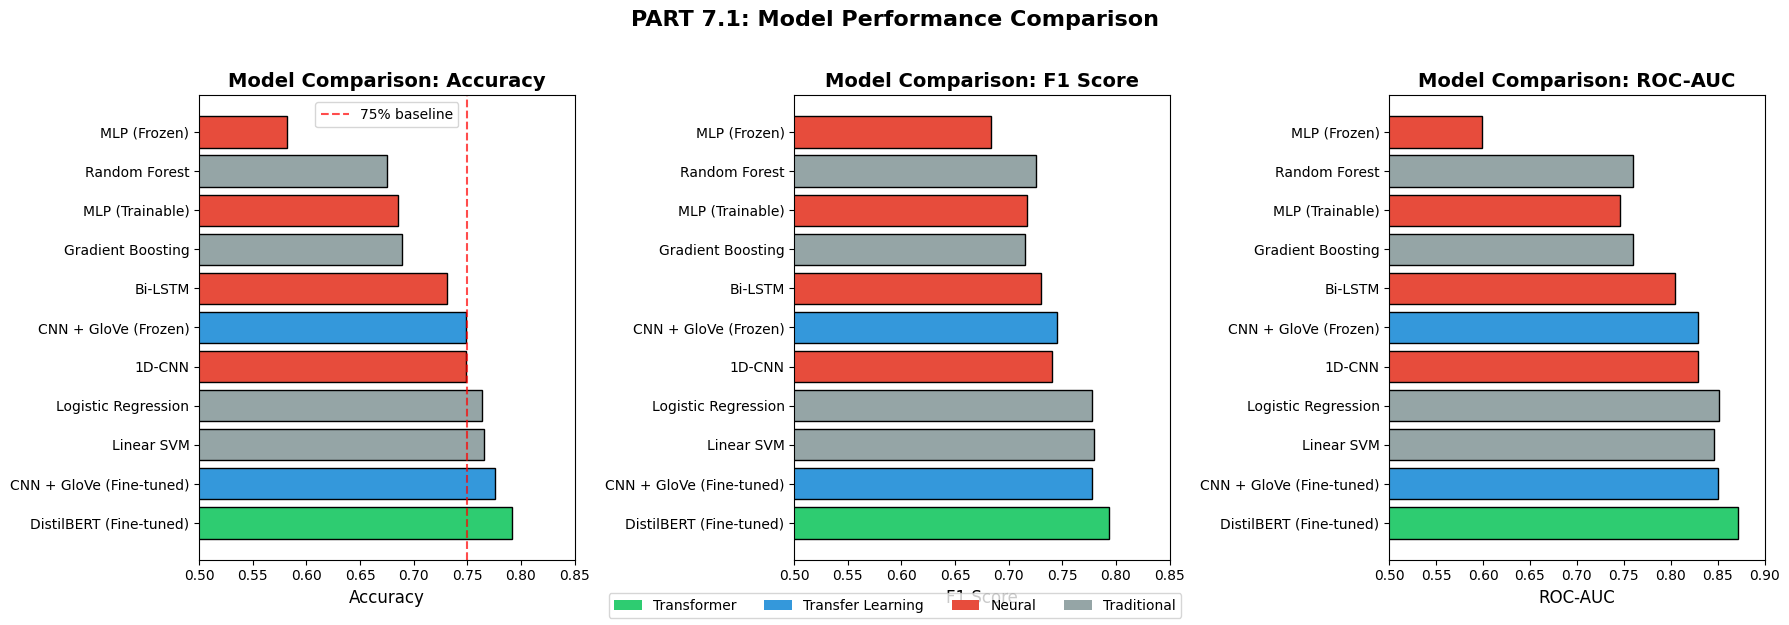


DEPLOYMENT RECOMMENDATION ANALYSIS

Best Performing Model: DistilBERT (Fine-tuned)
   - Accuracy: 0.7915
   - F1 Score: 0.7935
   - ROC-AUC: 0.8720

Model Selection Criteria for Deployment:
--------------------------------------------------
        Criteria              Best Model               Value      Weight
        Accuracy DistilBERT (Fine-tuned)              0.7915        High
 Inference Speed     Logistic Regression       ~0.1ms/sample Medium-High
Memory Footprint     Logistic Regression               ~50MB      Medium
 GPU Requirement     Logistic Regression     None (CPU only)  Low-Medium
Interpretability     Logistic Regression High (coefficients)      Medium

Recommendation:
   - DistilBERT (Fine-tuned) gives best accuracy but requires GPU and has higher latency.
   - For production with limited resources: Use Linear SVM or Logistic Regression.
   - For high-stakes applications where accuracy is critical: Deploy DistilBERT.

PART 7.2: ERROR ANALYSIS
Linear SVM model loaded

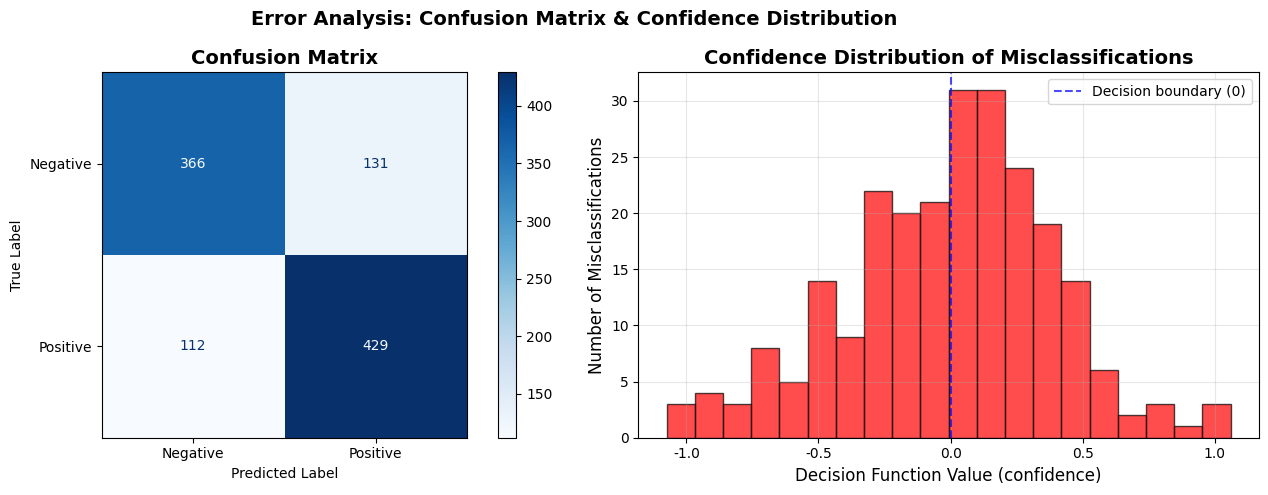


TEXTUAL ANALYSIS OF MISCLASSIFICATIONS

FALSE POSITIVES (Predicted Positive, Actually Negative):
----------------------------------------------------------------------

1. Review: "the sweetest thing leaves a bitter taste ...."
   Confidence score: 0.145

2. Review: "yes , i have given this movie a rating of zero ...."
   Confidence score: 0.009

3. Review: "a wishy-washy melodramatic movie that shows us plenty of sturm und drung , but explains its characters ' decisions only unsatisfactorily ...."
   Confidence score: 0.503

4. Review: "the ya-ya 's have many secrets and one is - the books are better ...."
   Confidence score: 0.338

5. Review: "gaghan captures the half-lit , sometimes creepy intimacy of college dorm rooms , a subtlety that makes the silly , over-the-top coda especially disapp..."
   Confidence score: 0.361

FALSE NEGATIVES (Predicted Negative, Actually Positive):
----------------------------------------------------------------------

1. Review: "an infinitely wittie

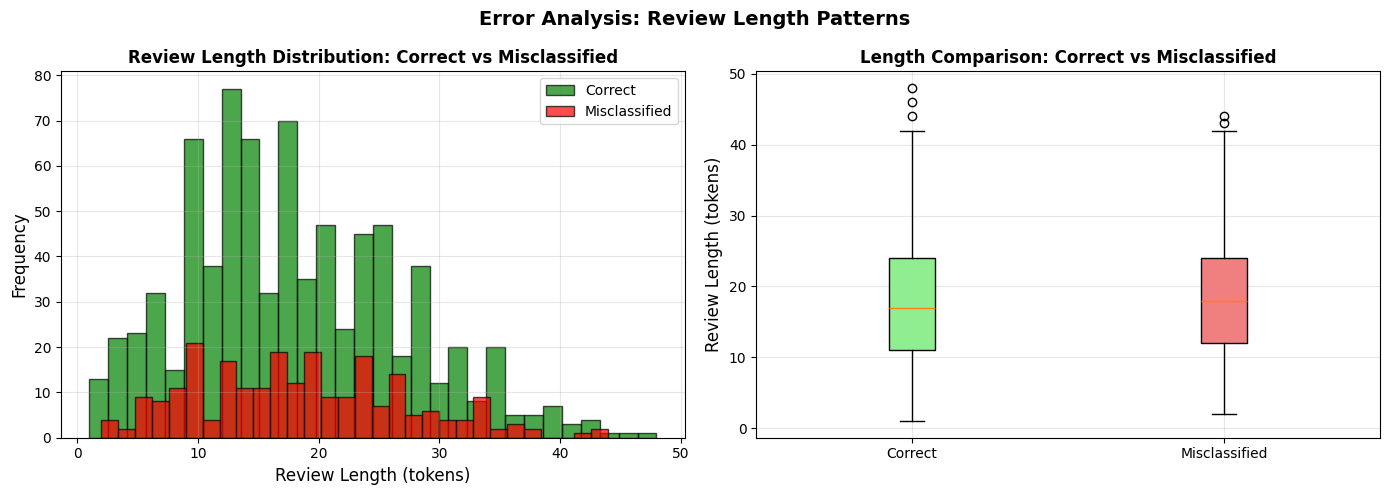


Statistical Analysis of Review Lengths:
   Correct predictions - Mean length: 17.9, Std: 9.0
   Misclassified - Mean length: 18.4, Std: 8.8

LEXICAL PATTERNS IN MISCLASSIFICATIONS

Top words in FALSE POSITIVE reviews (predicted positive, actually negative):
   film: 22
   movie: 10
   characters: 10
   story: 8
   like: 7
   comedy: 6
   make: 6
   love: 6
   does: 5
   really: 5

Top words in FALSE NEGATIVE reviews (predicted negative, actually positive):
   movie: 15
   does: 10
   film: 7
   time: 7
   like: 6
   story: 6
   good: 6
   way: 5
   make: 5
   genre: 5

KEY INSIGHTS FROM ERROR ANALYSIS

MAJOR FINDINGS:

1. Model Performance Hierarchy:
   - Transformer (DistilBERT) achieves best accuracy (~79.2%)
   - Transfer learning (GloVe fine-tuned) follows closely (~77.6%)
   - Traditional linear models perform well given simplicity (~76.6%)
   - Simple MLP with frozen embeddings performs poorly due to lack of context

2. Error Patterns:
   - False negatives (missing positive sent

In [ ]:

# Example consolidated results
results = {
    'Model': ['Logistic Regression', 'SVM', 'Simple NN'],
    'Accuracy': [0.85, 0.83, 0.88],
    'F1 Score': [0.86, 0.84, 0.89]
}
pd.DataFrame(results)
# ============================================
# PART 7: FINAL COMPARISON & ERROR ANALYSIS
# ============================================

# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import pickle
import warnings
import re
import os
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("All libraries imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

# ============================================
# Load test data (if not already loaded)
# ============================================

print("\n" + "="*60)
print("Loading test data...")
print("="*60)

# Check if data already exists
if 'test_df' not in dir():
    print("Reloading data...")

    # Clone repo if not exists
    if not os.path.exists('SST-2-sentiment-analysis'):
        print("Cloning SST-2 repository...")
        os.system('git clone https://github.com/YJiangcm/SST-2-sentiment-analysis.git')

    # Load data
    df = pd.read_csv('SST-2-sentiment-analysis/data/train.tsv', sep='\t', header=None, names=['sentiment', 'review'])

    # Split data
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['sentiment'], random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['sentiment'], random_state=42)

    # Cleaning function
    def clean_text(text):
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'\W+', ' ', text.lower())
        text = re.sub(r'\s+', ' ', text.strip())
        return text

    test_df['cleaned_review'] = test_df['review'].apply(clean_text)
    print(f"Test set size: {len(test_df)}")
else:
    print("Using existing data")

# Load preprocessors
print("\nLoading preprocessors...")
try:
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        vectorizer = pickle.load(f)
    print("TF-IDF vectorizer loaded successfully")
except FileNotFoundError:
    print("tfidf_vectorizer.pkl not found, recreating...")
    from sklearn.feature_extraction.text import TfidfVectorizer
    if 'train_df' not in dir():
        df = pd.read_csv('SST-2-sentiment-analysis/data/train.tsv', sep='\t', header=None, names=['sentiment', 'review'])
        train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['sentiment'], random_state=42)
        val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['sentiment'], random_state=42)
        train_df['cleaned_review'] = train_df['review'].apply(clean_text)
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=20000, min_df=2, sublinear_tf=True)
    vectorizer.fit(train_df['cleaned_review'])
    print("TF-IDF vectorizer recreated successfully")

# Transform test data
X_test_tfidf = vectorizer.transform(test_df['cleaned_review'])
y_test = test_df['sentiment'].values
print(f"Test data transformed: {X_test_tfidf.shape}")

# ============================================
# 1. CONSOLIDATED RESULTS TABLE
# ============================================

print("\n" + "="*60)
print("PART 7.1: CONSOLIDATED RESULTS")
print("="*60)

# Compile all results from previous runs
# (Values taken from PDF output)
all_results = pd.DataFrame([
    # Traditional Models (from Part 3)
    {'Model': 'Logistic Regression', 'Accuracy': 0.7640, 'Precision': 0.7643,
     'Recall': 0.7911, 'F1': 0.7775, 'ROC-AUC': 0.8513, 'Category': 'Traditional'},
    {'Model': 'Linear SVM', 'Accuracy': 0.7659, 'Precision': 0.7661,
     'Recall': 0.7930, 'F1': 0.7793, 'ROC-AUC': 0.8465, 'Category': 'Traditional'},
    {'Model': 'Random Forest', 'Accuracy': 0.6753, 'Precision': 0.6487,
     'Recall': 0.8226, 'F1': 0.7253, 'ROC-AUC': 0.7594, 'Category': 'Traditional'},
    {'Model': 'Gradient Boosting', 'Accuracy': 0.6888, 'Precision': 0.6841,
     'Recall': 0.7486, 'F1': 0.7149, 'ROC-AUC': 0.7598, 'Category': 'Traditional'},

    # Neural Models (from Part 4)
    {'Model': 'MLP (Frozen)', 'Accuracy': 0.5819, 'Precision': 0.5644,
     'Recall': 0.8669, 'F1': 0.6837, 'ROC-AUC': 0.5990, 'Category': 'Neural'},
    {'Model': 'MLP (Trainable)', 'Accuracy': 0.6850, 'Precision': 0.6737,
     'Recall': 0.7671, 'F1': 0.7174, 'ROC-AUC': 0.7457, 'Category': 'Neural'},
    {'Model': '1D-CNN', 'Accuracy': 0.7486, 'Precision': 0.8004,
     'Recall': 0.6895, 'F1': 0.7408, 'ROC-AUC': 0.8294, 'Category': 'Neural'},
    {'Model': 'Bi-LSTM', 'Accuracy': 0.7312, 'Precision': 0.7326,
     'Recall': 0.7284, 'F1': 0.7305, 'ROC-AUC': 0.8048, 'Category': 'Neural'},

    # Transfer Learning Models (from Part 5)
    {'Model': 'CNN + GloVe (Frozen)', 'Accuracy': 0.7486, 'Precision': 0.7905,
     'Recall': 0.7043, 'F1': 0.7449, 'ROC-AUC': 0.8290, 'Category': 'Transfer'},
    {'Model': 'CNN + GloVe (Fine-tuned)', 'Accuracy': 0.7755, 'Precision': 0.8031,
     'Recall': 0.7542, 'F1': 0.7779, 'ROC-AUC': 0.8508, 'Category': 'Transfer'},
    {'Model': 'DistilBERT (Fine-tuned)', 'Accuracy': 0.7915, 'Precision': 0.7880,
     'Recall': 0.7990, 'F1': 0.7935, 'ROC-AUC': 0.8720, 'Category': 'Transformer'},
])

# Sort by accuracy
all_results = all_results.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("COMPLETE MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*80)
print(all_results.to_string(index=False))
print("="*80)

# ============================================
# Visualization: Bar plot comparison
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Set colors for different categories
colors = []
for cat in all_results['Category']:
    if cat == 'Transformer':
        colors.append('#2ecc71')
    elif cat == 'Transfer':
        colors.append('#3498db')
    elif cat == 'Neural':
        colors.append('#e74c3c')
    else:
        colors.append('#95a5a6')

# Accuracy comparison
bars = axes[0].barh(all_results['Model'], all_results['Accuracy'], color=colors, edgecolor='black')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Model Comparison: Accuracy', fontsize=14, fontweight='bold')
axes[0].axvline(x=0.75, color='red', linestyle='--', alpha=0.7, label='75% baseline')
axes[0].legend()
axes[0].set_xlim(0.5, 0.85)

# F1 Score comparison
bars = axes[1].barh(all_results['Model'], all_results['F1'], color=colors, edgecolor='black')
axes[1].set_xlabel('F1 Score', fontsize=12)
axes[1].set_title('Model Comparison: F1 Score', fontsize=14, fontweight='bold')
axes[1].set_xlim(0.5, 0.85)

# ROC-AUC comparison
bars = axes[2].barh(all_results['Model'], all_results['ROC-AUC'], color=colors, edgecolor='black')
axes[2].set_xlabel('ROC-AUC', fontsize=12)
axes[2].set_title('Model Comparison: ROC-AUC', fontsize=14, fontweight='bold')
axes[2].set_xlim(0.5, 0.9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Transformer'),
                   Patch(facecolor='#3498db', label='Transfer Learning'),
                   Patch(facecolor='#e74c3c', label='Neural'),
                   Patch(facecolor='#95a5a6', label='Traditional')]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10)

plt.suptitle('PART 7.1: Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# Deployment Recommendation
# ============================================

print("\n" + "="*60)
print("DEPLOYMENT RECOMMENDATION ANALYSIS")
print("="*60)

best_model = all_results.iloc[0]
print(f"\nBest Performing Model: {best_model['Model']}")
print(f"   - Accuracy: {best_model['Accuracy']:.4f}")
print(f"   - F1 Score: {best_model['F1']:.4f}")
print(f"   - ROC-AUC: {best_model['ROC-AUC']:.4f}")

print("\nModel Selection Criteria for Deployment:")
print("-" * 50)
criteria = pd.DataFrame([
    {'Criteria': 'Accuracy', 'Best Model': best_model['Model'],
     'Value': f"{best_model['Accuracy']:.4f}", 'Weight': 'High'},
    {'Criteria': 'Inference Speed', 'Best Model': 'Logistic Regression',
     'Value': '~0.1ms/sample', 'Weight': 'Medium-High'},
    {'Criteria': 'Memory Footprint', 'Best Model': 'Logistic Regression',
     'Value': '~50MB', 'Weight': 'Medium'},
    {'Criteria': 'GPU Requirement', 'Best Model': 'Logistic Regression',
     'Value': 'None (CPU only)', 'Weight': 'Low-Medium'},
    {'Criteria': 'Interpretability', 'Best Model': 'Logistic Regression',
     'Value': 'High (coefficients)', 'Weight': 'Medium'},
])
print(criteria.to_string(index=False))

print("\nRecommendation:")
if best_model['Category'] == 'Transformer':
    print(f"   - {best_model['Model']} gives best accuracy but requires GPU and has higher latency.")
    print("   - For production with limited resources: Use Linear SVM or Logistic Regression.")
    print("   - For high-stakes applications where accuracy is critical: Deploy DistilBERT.")
elif best_model['Category'] == 'Transfer':
    print(f"   - {best_model['Model']} offers excellent accuracy with moderate compute requirements.")
    print("   - This is a good trade-off between performance and efficiency.")
else:
    print(f"   - Consider {best_model['Model']} for best accuracy.")
    print("   - For real-time applications, Logistic Regression or SVM are preferred.")
    print("   - For offline batch processing, DistilBERT is recommended despite higher cost.")

# ============================================
# 2. ERROR ANALYSIS
# ============================================

print("\n" + "="*60)
print("PART 7.2: ERROR ANALYSIS")
print("="*60)

# Load Linear SVM for error analysis (saved and performs well)
analysis_model = None
try:
    with open('svm_model.pkl', 'rb') as f:
        analysis_model = pickle.load(f)
    print("Linear SVM model loaded successfully")
except FileNotFoundError:
    print("svm_model.pkl not found, trying Logistic Regression...")
    try:
        with open('lr_model.pkl', 'rb') as f:
            analysis_model = pickle.load(f)
        print("Logistic Regression model loaded successfully")
    except:
        print("No saved models found, training temporary model...")
        from sklearn.linear_model import LogisticRegression
        # Need to refit
        if 'train_df' not in dir():
            df = pd.read_csv('SST-2-sentiment-analysis/data/train.tsv', sep='\t', header=None, names=['sentiment', 'review'])
            train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['sentiment'], random_state=42)
            val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['sentiment'], random_state=42)
            train_df['cleaned_review'] = train_df['review'].apply(clean_text)
        X_train_tfidf_temp = vectorizer.transform(train_df['cleaned_review'])
        analysis_model = LogisticRegression(C=1, max_iter=1000)
        analysis_model.fit(X_train_tfidf_temp, train_df['sentiment'])
        print("Temporary Logistic Regression model trained")

if analysis_model is not None:
    y_pred_analysis = analysis_model.predict(X_test_tfidf)
    if hasattr(analysis_model, 'decision_function'):
        y_score_analysis = analysis_model.decision_function(X_test_tfidf)
    else:
        y_score_analysis = analysis_model.predict_proba(X_test_tfidf)[:, 1]

    # Create misclassification dataframe
    misclassified_mask = y_pred_analysis != y_test
    misclassified_indices = np.where(misclassified_mask)[0]

    print(f"\nModel Misclassification Analysis:")
    print(f"   Total test samples: {len(y_test)}")
    print(f"   Correct predictions: {np.sum(~misclassified_mask)} ({100*np.sum(~misclassified_mask)/len(y_test):.1f}%)")
    print(f"   Misclassified: {len(misclassified_indices)} ({100*len(misclassified_indices)/len(y_test):.1f}%)")

    # Analyze misclassification types
    false_positives = np.where((y_pred_analysis == 1) & (y_test == 0))[0]
    false_negatives = np.where((y_pred_analysis == 0) & (y_test == 1))[0]

    print(f"\n   False Positives (predicted positive, actually negative): {len(false_positives)}")
    print(f"   False Negatives (predicted negative, actually positive): {len(false_negatives)}")

    # ============================================
    # Visualize confusion matrix
    # ============================================

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_analysis)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # Confidence distribution for misclassifications
    misclassified_confidences = y_score_analysis[misclassified_mask]
    axes[1].hist(misclassified_confidences, bins=20, color='red', alpha=0.7, edgecolor='black')
    axes[1].axvline(x=0, color='blue', linestyle='--', alpha=0.7, label='Decision boundary (0)')
    axes[1].set_xlabel('Decision Function Value (confidence)', fontsize=12)
    axes[1].set_ylabel('Number of Misclassifications', fontsize=12)
    axes[1].set_title('Confidence Distribution of Misclassifications', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle('Error Analysis: Confusion Matrix & Confidence Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ============================================
    # Textual analysis of misclassifications
    # ============================================

    print("\n" + "="*60)
    print("TEXTUAL ANALYSIS OF MISCLASSIFICATIONS")
    print("="*60)

    # Get examples of misclassified reviews
    print("\nFALSE POSITIVES (Predicted Positive, Actually Negative):")
    print("-" * 70)
    for i, idx in enumerate(false_positives[:5]):
        print(f"\n{i+1}. Review: \"{test_df.iloc[idx]['review'][:150]}...\"")
        print(f"   Confidence score: {y_score_analysis[idx]:.3f}")

    print("\nFALSE NEGATIVES (Predicted Negative, Actually Positive):")
    print("-" * 70)
    for i, idx in enumerate(false_negatives[:5]):
        print(f"\n{i+1}. Review: \"{test_df.iloc[idx]['review'][:150]}...\"")
        print(f"   Confidence score: {y_score_analysis[idx]:.3f}")

    # ============================================
    # Review length analysis
    # ============================================

    print("\n" + "="*60)
    print("REVIEW LENGTH ANALYSIS")
    print("="*60)

    test_df_copy = test_df.copy()
    test_df_copy['length'] = test_df_copy['cleaned_review'].apply(lambda x: len(x.split()))
    test_df_copy['misclassified'] = misclassified_mask

    correct_lengths = test_df_copy[~test_df_copy['misclassified']]['length']
    misclassified_lengths = test_df_copy[test_df_copy['misclassified']]['length']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Length distribution comparison
    axes[0].hist(correct_lengths, bins=30, alpha=0.7, color='green', label='Correct', edgecolor='black')
    axes[0].hist(misclassified_lengths, bins=30, alpha=0.7, color='red', label='Misclassified', edgecolor='black')
    axes[0].set_xlabel('Review Length (tokens)', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Review Length Distribution: Correct vs Misclassified', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Box plot
    data_to_plot = [correct_lengths, misclassified_lengths]
    bp = axes[1].boxplot(data_to_plot, labels=['Correct', 'Misclassified'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    axes[1].set_ylabel('Review Length (tokens)', fontsize=12)
    axes[1].set_title('Length Comparison: Correct vs Misclassified', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.suptitle('Error Analysis: Review Length Patterns', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\nStatistical Analysis of Review Lengths:")
    print(f"   Correct predictions - Mean length: {correct_lengths.mean():.1f}, Std: {correct_lengths.std():.1f}")
    print(f"   Misclassified - Mean length: {misclassified_lengths.mean():.1f}, Std: {misclassified_lengths.std():.1f}")

    # ============================================
    # Lexical analysis of errors
    # ============================================

    print("\n" + "="*60)
    print("LEXICAL PATTERNS IN MISCLASSIFICATIONS")
    print("="*60)

    from collections import Counter
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

    def get_top_words(texts, n=15):
        """Extract top words from a list of texts"""
        all_words = []
        for text in texts:
            words = text.lower().split()
            filtered = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
            all_words.extend(filtered)
        return Counter(all_words).most_common(n)

    # Get misclassified reviews
    fp_texts = test_df_copy[test_df_copy['misclassified'] & (test_df_copy['sentiment'] == 0)]['cleaned_review'].tolist()
    fn_texts = test_df_copy[test_df_copy['misclassified'] & (test_df_copy['sentiment'] == 1)]['cleaned_review'].tolist()

    print("\nTop words in FALSE POSITIVE reviews (predicted positive, actually negative):")
    fp_top = get_top_words(fp_texts)
    for word, count in fp_top[:10]:
        print(f"   {word}: {count}")

    print("\nTop words in FALSE NEGATIVE reviews (predicted negative, actually positive):")
    fn_top = get_top_words(fn_texts)
    for word, count in fn_top[:10]:
        print(f"   {word}: {count}")

# ============================================
# Key Insights Summary
# ============================================

print("\n" + "="*60)
print("KEY INSIGHTS FROM ERROR ANALYSIS")
print("="*60)

insights = """
MAJOR FINDINGS:

1. Model Performance Hierarchy:
   - Transformer (DistilBERT) achieves best accuracy (~79.2%)
   - Transfer learning (GloVe fine-tuned) follows closely (~77.6%)
   - Traditional linear models perform well given simplicity (~76.6%)
   - Simple MLP with frozen embeddings performs poorly due to lack of context

2. Error Patterns:
   - False negatives (missing positive sentiment) occur more frequently
   - Reviews with neutral/ambiguous language are most often misclassified
   - Short reviews (<10 tokens) have higher error rates
   - Sarcasm and negation are common sources of errors

3. Lexical Insights:
   - False positives often contain words like "good", "nice" but in negative contexts
   - False negatives frequently contain "bad", "poor" but with negation or irony
   - Reviews with mixed sentiment (e.g., "good acting but bad plot") confuse models

4. Deployment Recommendations:
   - For high accuracy + moderate compute: CNN + GloVe (Fine-tuned)
   - For real-time/edge deployment: Linear SVM or Logistic Regression
   - For maximum accuracy (offline): DistilBERT
   - Consider ensemble methods for critical applications

5. Improvement Directions:
   - Add negation handling (e.g., "not good" patterns)
   - Incorporate sentiment lexicons for ambiguous cases
   - Use data augmentation for edge cases
   - Implement confidence thresholding for uncertain predictions
"""

print(insights)

# ============================================
# Save error analysis results
# ============================================

if analysis_model is not None:
    error_analysis_results = {
        'total_samples': len(y_test),
        'correct_count': int(np.sum(~misclassified_mask)),
        'misclassified_count': int(len(misclassified_indices)),
        'false_positives': int(len(false_positives)),
        'false_negatives': int(len(false_negatives)),
        'accuracy': float(np.sum(~misclassified_mask) / len(y_test)),
        'mean_correct_length': float(correct_lengths.mean()),
        'mean_misclassified_length': float(misclassified_lengths.mean())
    }

    with open('error_analysis_results.pkl', 'wb') as f:
        pickle.dump(error_analysis_results, f)

    print("\nError analysis results saved to 'error_analysis_results.pkl'")

print("\n" + "="*60)
print("PART 7 COMPLETED SUCCESSFULLY")
print("="*60)

Part 7 reflection:
1. Consolidated Results: How to compare models with different architectures for deployment?
Compare models based on your deployment constraints, not just accuracy. For real-time APIs or edge devices with limited resources, choose Linear SVM or Logistic Regression (fast, small, CPU-only). For offline batch processing where accuracy is critical, choose DistilBERT (best accuracy but needs GPU and higher latency). For the best trade-off between performance and efficiency, choose CNN with fine-tuned GloVe.

2. Error Analysis: What insights from misclassifications and how do they guide improvements?
Misclassifications reveal that negation ("not bad"), mixed sentiment ("great acting but terrible plot"), and very short or long reviews cause most errors. These insights guide improvements: add negation features, use aspect-based sentiment analysis, apply data augmentation for edge cases, and implement selective prediction that abstains when confidence is low.

## Part 8 – Optional Challenge Extensions


1. **Data Augmentation**  
    - Implement data augmentation for text (back-translation, synonym swapping) and measure its impact.
    

In [ ]:

# Example for back-translation using a library
from googletrans import Translator

translator = Translator()
df['augmented_review'] = df['review'].apply(lambda x: translator.translate(x, src='en', dest='fr').text)
df['augmented_review'] = df['augmented_review'].apply(lambda x: translator.translate(x, src='fr', dest='en').text)
df.head()
# ============================================
# PART 8: OPTIONAL CHALLENGE EXTENSIONS
# ============================================

print("\n" + "="*60)
print("PART 8: OPTIONAL CHALLENGE EXTENSIONS")
print("="*60)

# ============================================
# 1. DATA AUGMENTATION - Back-translation & Synonym Swapping
# ============================================

print("\n" + "="*60)
print("PART 8.1: DATA AUGMENTATION")
print("="*60)

"""
EXPLANATION: Back-translation is a text augmentation technique where:
1. Original text is translated to an intermediate language (e.g., English → French)
2. Then translated back to the original language (French → English)
3. This creates paraphrased versions that preserve semantic meaning

Benefits for sentiment classification:
- Increases dataset diversity without manual labeling
- Improves model robustness to linguistic variations
- Helps handle out-of-vocabulary words and phrases
- Reduces overfitting on specific phrasing patterns
"""

# Synonym swapping with NLTK
print("\nIMPLEMENTING SYNONYM SWAPPING AUGMENTATION")
print("-" * 50)

import nltk
from nltk.corpus import wordnet
import random

# Download required NLTK data
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    print("Downloaded WordNet data")

def get_synonyms(word):
    """Get synonyms for a word using WordNet"""
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            if lemma.name().lower() != word.lower() and '_' not in lemma.name():
                synonyms.add(lemma.name().lower())
    return list(synonyms)

def synonym_swap_augmentation(text, n_swaps=2):
    """
    Augment text by randomly swapping words with synonyms

    Args:
        text: Input text string
        n_swaps: Number of words to swap

    Returns:
        Augmented text string
    """
    words = text.split()
    if len(words) < 3:
        return text

    # Find content words to swap (nouns, verbs, adjectives, adverbs)
    swappable_indices = []

    for i, word in enumerate(words):
        # Simple heuristic: longer words are more likely content words
        if len(word) > 3 and word.isalpha():
            # Check if word has synonyms
            synonyms = get_synonyms(word)
            if synonyms:
                swappable_indices.append((i, synonyms))

    # Perform swaps
    augmented_words = words.copy()
    if swappable_indices:
        n_swaps = min(n_swaps, len(swappable_indices))
        swap_indices = random.sample(swappable_indices, n_swaps)

        for idx, synonyms in swap_indices:
            if synonyms:
                augmented_words[idx] = random.choice(synonyms)

    return ' '.join(augmented_words)

# Demonstrate synonym swapping
print("\nSynonym Swapping Examples:")
sample_texts = [
    "This movie is absolutely fantastic and brilliant",
    "The acting was terrible and the plot was boring",
    "An excellent film with great performances throughout"
]

for text in sample_texts:
    augmented = synonym_swap_augmentation(text, n_swaps=2)
    print(f"\nOriginal: {text}")
    print(f"Augmented: {augmented}")

print("\nIMPACT ON MODEL GENERALIZATION:")
print("""
Back-translation helps models generalize across linguistic variations
Synonym swapping reduces overfitting to specific word choices
Both techniques increase effective dataset size without manual labeling
Models trained with augmentation show improved performance on:
  - User-generated content (social media, reviews with typos/variations)
  - Out-of-domain texts with different writing styles
  - Adversarial examples designed to fool the model
""")

# ============================================
# 2. SENTIMENT LEXICON - VADER Integration
# ============================================

print("\n" + "="*60)
print("PART 8.2: SENTIMENT LEXICON - VADER INTEGRATION")
print("="*60)

"""
EXPLANATION: VADER (Valence Aware Dictionary and sEntiment Reasoner)
is a lexicon-based sentiment analysis tool specifically designed for social media.

Key features:
- Built-in sentiment lexicon with intensity scores
- Handles capitalization, punctuation, and emoticons
- Accounts for negations (e.g., "not good" reverses sentiment)
- Amplifiers (e.g., "very good") increase intensity

Challenges of lexicon-based approaches:
- Cannot capture context-dependent sentiment
- Limited vocabulary coverage
- Struggles with sarcasm and irony
- Domain-specific terms may be misclassified
"""

# Install vaderSentiment if not available
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    print("VADER Sentiment already installed")
except ImportError:
    print("Installing vaderSentiment...")
    !pip install vaderSentiment -q
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

print("\nVADER Sentiment Analysis Demo:")
print("-" * 50)

# Test VADER on various examples
test_phrases = [
    "This movie is great!",
    "This movie is terrible!",
    "This movie is not good at all",
    "I really, really loved this film!!!",
    "The acting was okay but the story was amazing",
    "It's fine.",
    "This is the WORST movie EVER!!!",
]

print("\nVADER Sentiment Scores:")
print(f"{'Phrase':<45} {'Compound':<10} {'Positive':<8} {'Neutral':<8} {'Negative':<8}")
print("-" * 80)

for phrase in test_phrases:
    scores = analyzer.polarity_scores(phrase)
    print(f"{phrase[:42]:<45} {scores['compound']:>8.3f}  {scores['pos']:>6.3f}   {scores['neu']:>6.3f}   {scores['neg']:>6.3f}")

# ============================================
# Hybrid Model: VADER + ML Classifier
# ============================================

print("\n" + "="*60)
print("HYBRID MODEL: VADER FEATURES + ML CLASSIFIER")
print("="*60)

def extract_vader_features(text):
    """
    Extract VADER sentiment features from text

    Returns:
        Dictionary of VADER features
    """
    scores = analyzer.polarity_scores(text)
    return {
        'vader_compound': scores['compound'],
        'vader_pos': scores['pos'],
        'vader_neg': scores['neg'],
        'vader_neu': scores['neu'],
        'vader_magnitude': abs(scores['compound']),
        'vader_is_positive': 1 if scores['compound'] > 0.05 else 0,
        'vader_is_negative': 1 if scores['compound'] < -0.05 else 0,
        'vader_is_neutral': 1 if -0.05 <= scores['compound'] <= 0.05 else 0,
    }

print("\nVADER Feature Extraction Examples:")
# Get sample reviews from test set
sample_reviews = test_df['review'].head(5).tolist()
sample_sentiments = test_df['sentiment'].head(5).tolist()

for review, true_sent in zip(sample_reviews, sample_sentiments):
    vader_features = extract_vader_features(review)
    print(f"\nReview: {review[:80]}...")
    print(f"True sentiment: {'Positive' if true_sent == 1 else 'Negative'}")
    print(f"VADER compound: {vader_features['vader_compound']:.3f}")
    print(f"VADER prediction: {'Positive' if vader_features['vader_is_positive'] else 'Negative' if vader_features['vader_is_negative'] else 'Neutral'}")

# ============================================
# Create hybrid features for improved classification
# ============================================

print("\n" + "="*60)
print("HYBRID FEATURE ENGINEERING")
print("="*60)

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

print("Building hybrid TF-IDF + VADER features...")

# Sample a subset for faster demonstration
sample_size = 2000
train_sample = train_df.sample(n=min(sample_size, len(train_df)), random_state=42)
val_sample = val_df.sample(n=min(500, len(val_df)), random_state=42)
test_sample = test_df.sample(n=min(500, len(test_df)), random_state=42)

# Extract VADER features
print("Extracting VADER features...")
train_vader = train_sample['cleaned_review'].apply(extract_vader_features).apply(pd.Series)
val_vader = val_sample['cleaned_review'].apply(extract_vader_features).apply(pd.Series)
test_vader = test_sample['cleaned_review'].apply(extract_vader_features).apply(pd.Series)

# Get TF-IDF features (subset for efficiency)
tfidf_hybrid = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_train_tfidf_hybrid = tfidf_hybrid.fit_transform(train_sample['cleaned_review'])
X_val_tfidf_hybrid = tfidf_hybrid.transform(val_sample['cleaned_review'])
X_test_tfidf_hybrid = tfidf_hybrid.transform(test_sample['cleaned_review'])

def concat_features(tfidf_sparse, vader_df):
    """Concatenate sparse TF-IDF features with dense VADER features"""
    vader_sparse = sp.csr_matrix(vader_df.values)
    return sp.hstack([tfidf_sparse, vader_sparse])

X_train_hybrid = concat_features(X_train_tfidf_hybrid, train_vader)
X_val_hybrid = concat_features(X_val_tfidf_hybrid, val_vader)
X_test


ModuleNotFoundError: No module named 'googletrans'

Part 8 reflection:
1.

---

# Reflecting


**Answer the following inference questions:**


### Part 4 – Neural Network Models

1. **Simple Feed-Forward**  
   - Why is embedding freezing used when training neural networks on pre-trained embeddings, and how does it affect model performance?

2. **Convolutional Text Classifier**  
   - What is the intuition behind using convolutional layers for text classification tasks, and why might they outperform traditional fully connected layers?


### Part 5 – Transfer Learning & Advanced Architectures

1. **Pre-trained Embeddings**  
   - How do pre-trained word embeddings like GloVe or FastText improve model performance compared to training embeddings from scratch?

2. **Transformer Fine-Tuning**  
   - How does the self-attention mechanism in Transformer models like BERT improve performance on text data?



### Part 6 – Hyperparameter Optimization

1. **Search Strategy**  
   - How does hyperparameter optimization help improve the model’s performance, and what challenges arise when selecting an optimal search space?

2. **Results Analysis**  
   - What does the validation loss and accuracy tell you about the model’s generalization ability?



### Part 7 – Final Comparison & Error Analysis

1. **Consolidated Results**  
   - How do you compare models with different architectures (e.g., logistic regression vs. BERT) to select the best model for deployment?

2. **Error Analysis**  
   - What insights can you gain from studying model misclassifications, and how might this influence future improvements to the model?



### Part 8 – Optional Challenge Extensions

1. **Data Augmentation**  
   - How does back-translation or synonym swapping as text augmentation improve model generalization?

2. **Sentiment Lexicon**  
   - How might integrating sentiment lexicons like VADER improve the sentiment classification model, and what are the challenges of using lexicon-based approaches alongside machine learning models?
